# Multi-Source Fusion for BD Detection

This notebook combines:
- **Text**: Reddit (current) + Kaggle BD + Multi-class Depression Twitter
- **Physio**: WESAD (26D) + OBF-Psychiatric (24D)

Expected Results:
- Unimodal Text (multi-source): 95-97% F1
- Unimodal Physio (multi-source): 96-97% F1
- **Bimodal Fusion: 98-99% F1** ✅

To evaluate the reliability of bimodal and multimodal fusion for bipolar disorder state classification by comparing aligned fusion, misaligned fusion, and noise-based controls.

In [1]:
## 1. Setup & Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Install required packages
!pip install transformers datasets scikit-learn imbalanced-learn vaderSentiment -q
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
import torch
import random
from transformers import BertTokenizer, BertModel
from tqdm import tqdm

# Set random seeds
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# UPDATE THIS PATH
WESAD_PATH = '/content/drive/MyDrive/Research on BD NYU /development/WESAD/WESAD'

def load_wesad_subject(base_path, subject_id):
    """Load WESAD subject data"""
    subject_path = os.path.join(base_path, f'S{subject_id}', f'S{subject_id}.pkl')
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

def quick_wesad_dataframe(subject_data, window_sec=1):
    """
    Extract 26D features from WESAD (same as notebook 03 - 99% F1 method)

    Features:
    - Chest: ECG, EDA, EMG, Temp, Resp (5 sensors × 2 stats = 10)
    - Chest ACC: x, y, z (3 axes × 2 stats = 6)
    - Wrist: BVP, EDA (2 sensors × 2 stats = 4)
    - Wrist ACC: x, y, z (3 axes × 2 stats = 6)
    Total: 26 features
    """
    # Sampling rates
    fs_chest = 700
    fs_wrist_bvp = 64
    fs_wrist_eda = 4
    fs_wrist_acc = 32

    chest = subject_data['signal']['chest']
    wrist = subject_data['signal']['wrist']
    labels = subject_data['label']

    # Calculate number of windows
    n_samples = len(chest['ECG'])
    n_windows = n_samples // (fs_chest * window_sec)

    features = {}

    # --- Chest signals (700Hz) ---
    for signal_name in ['ECG', 'EDA', 'EMG', 'Temp', 'Resp']:
        if signal_name in chest:
            sig = chest[signal_name][:n_windows * fs_chest]
            sig = sig.reshape((n_windows, fs_chest * window_sec))
            features[f'chest_{signal_name.lower()}_mean'] = np.mean(sig, axis=1)
            features[f'chest_{signal_name.lower()}_std'] = np.std(sig, axis=1)

    # --- Chest ACC (700Hz, 3 axes) ---
    if 'ACC' in chest:
        acc = chest['ACC'][:n_windows * fs_chest]
        acc = acc.reshape((n_windows, fs_chest * window_sec, 3))
        for i, axis in enumerate(['x', 'y', 'z']):
            features[f'chest_acc_{axis}_mean'] = np.mean(acc[:, :, i], axis=1)
            features[f'chest_acc_{axis}_std'] = np.std(acc[:, :, i], axis=1)

    # --- Wrist BVP (64Hz) ---
    if 'BVP' in wrist:
        bvp = wrist['BVP'][:n_windows * fs_wrist_bvp * window_sec]
        bvp = bvp.reshape((n_windows, fs_wrist_bvp * window_sec))
        features['wrist_bvp_mean'] = np.mean(bvp, axis=1)
        features['wrist_bvp_std'] = np.std(bvp, axis=1)

    # --- Wrist EDA (4Hz) ---
    if 'EDA' in wrist:
        eda = wrist['EDA'][:n_windows * fs_wrist_eda * window_sec]
        eda = eda.reshape((n_windows, fs_wrist_eda * window_sec))
        features['wrist_eda_mean'] = np.mean(eda, axis=1)
        features['wrist_eda_std'] = np.std(eda, axis=1)

    # --- Wrist ACC (32Hz, 3 axes) ---
    if 'ACC' in wrist:
        acc = wrist['ACC'][:n_windows * fs_wrist_acc * window_sec]
        acc = acc.reshape((n_windows, fs_wrist_acc * window_sec, 3))
        for i, axis in enumerate(['x', 'y', 'z']):
            features[f'wrist_acc_{axis}_mean'] = np.mean(acc[:, :, i], axis=1)
            features[f'wrist_acc_{axis}_std'] = np.std(acc[:, :, i], axis=1)

    # --- Labels (majority vote per window) ---
    label_samples = labels[:n_windows * fs_chest]
    label_samples = label_samples.reshape((n_windows, fs_chest * window_sec))
    window_labels = np.array([np.bincount(window.astype(int)).argmax() for window in label_samples])
    features['label'] = window_labels

    return pd.DataFrame(features)

def map_to_bipolar_state(original_label):
    """Map WESAD stress labels to BD states"""
    if original_label in [0, 3]:  # Baseline, Meditation
        return 0  # Euthymia
    elif original_label in [1, 6]:  # Stress
        return 1  # Depression
    elif original_label in [2, 4]:  # Amusement
        return 2  # Mania
    else:
        return None  # Ignore label 7

In [ ]:
# Process all WESAD subjects
print("Processing WESAD subjects...")
wesad_dfs = []
subject_ids = list(range(2, 18))  # S2-S17

for sid in tqdm(subject_ids, desc="WESAD subjects"):
    try:
        data = load_wesad_subject(WESAD_PATH, sid)
        df = quick_wesad_dataframe(data, window_sec=1)
        df['bipolar_state'] = df['label'].apply(map_to_bipolar_state)
        df = df.dropna(subset=['bipolar_state'])
        wesad_dfs.append(df)
        print(f"✓ S{sid}: {len(df)} windows")
    except Exception as e:
        print(f"✗ S{sid}: {e}")

wesad_combined = pd.concat(wesad_dfs, ignore_index=True)
print(f"\nTotal WESAD windows: {len(wesad_combined)}")
print(f"Distribution:\n{wesad_combined['bipolar_state'].value_counts()}")

Processing WESAD subjects...


WESAD subjects:   6%|▋         | 1/16 [00:04<01:09,  4.61s/it]

✓ S2: 6015 windows


WESAD subjects:  12%|█▎        | 2/16 [00:09<01:06,  4.73s/it]

✓ S3: 6353 windows


...

✓ S15: 5156 windows


WESAD subjects:  94%|█████████▍| 15/16 [00:39<00:02,  2.73s/it]

✓ S16: 5523 windows


WESAD subjects: 100%|██████████| 16/16 [00:52<00:00,  3.30s/it]

✓ S17: 5805 windows

Total WESAD windows: 62708
Distribution:
bipolar_state
0.0    33228
2.0    16001
1.0    13479
Name: count, dtype: int64


In [ ]:
# Balance WESAD classes
euth = wesad_combined[wesad_combined['bipolar_state'] == 0]
depr = wesad_combined[wesad_combined['bipolar_state'] == 1]
mani = wesad_combined[wesad_combined['bipolar_state'] == 2]

min_count = min(len(euth), len(depr), len(mani))
print(f"Balancing to {min_count} samples per class...")

wesad_balanced = pd.concat([
    resample(euth, n_samples=min_count, random_state=42),
    resample(depr, n_samples=min_count, random_state=42),
    resample(mani, n_samples=min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced distribution:\n{wesad_balanced['bipolar_state'].value_counts()}")
print(f"\nWESAD feature shape: {wesad_balanced.drop(['label', 'bipolar_state'], axis=1).shape}")

Balancing to 13479 samples per class...
Balanced distribution:
bipolar_state
2.0    13479
0.0    13479
1.0    13479
Name: count, dtype: int64

WESAD feature shape: (40437, 26)


In [ ]:
# UPDATE THIS PATH
OBF_PATH = '/content/drive/MyDrive/Research on BD NYU /development/OBF-Psychiatric Dataset'

# Load all OBF files
print("Loading OBF-Psychiatric data...")
obf_dfs = []

for filename in os.listdir(OBF_PATH):
    file_path = os.path.join(OBF_PATH, filename)
    if os.path.isfile(file_path) and filename.endswith('.csv'):
        try:
            df = pd.read_csv(file_path)
            obf_dfs.append(df)
        except Exception as e:
            print(f"Error reading {filename}: {e}")

obf_combined = pd.concat(obf_dfs, ignore_index=True)
print(f"Total OBF samples: {len(obf_combined)}")

Loading OBF-Psychiatric data...
Total OBF samples: 1059


In [ ]:
# Feature extraction (8 features from OBF dataset)
# These capture motor activity and clinical assessment scores
features = ['mean', 'sd', 'pctZeros', 'median', 'madrs', 'hads_d', 'asrs', 'mdq_pos']
X_obf = obf_combined[features].fillna(obf_combined[features].mean())

# ⚠️ CRITICAL FIX: Split into train/test BEFORE any preprocessing to avoid data leakage
print("Splitting OBF data before preprocessing to avoid data leakage...")
from sklearn.model_selection import train_test_split

# Split indices (not data yet - we'll use these to track train/test throughout)
obf_train_idx, obf_test_idx = train_test_split(
    np.arange(len(X_obf)), test_size=0.2, random_state=42, stratify=None
)

X_obf_train = X_obf.iloc[obf_train_idx].values
X_obf_test = X_obf.iloc[obf_test_idx].values

# Standardize (FIT on train only, TRANSFORM both)
scaler = StandardScaler()
X_obf_train_scaled = scaler.fit_transform(X_obf_train)  # Fit on train
X_obf_test_scaled = scaler.transform(X_obf_test)  # Use train statistics

print(f"✓ OBF train: {X_obf_train_scaled.shape}")
print(f"✓ OBF test: {X_obf_test_scaled.shape}")

# Store for use in next cell
print(f"\nOBF features: {X_obf.shape[1]}D (using all features)")
print(f"✓ Preprocessing done with proper train/test isolation")

Splitting OBF data before preprocessing to avoid data leakage...
✓ OBF train: (847, 8)
✓ OBF test: (212, 8)

OBF features: 8D (using all features)
✓ Preprocessing done with proper train/test isolation


In [ ]:
# Use autoencoder + GMM clustering to assign labels (PyTorch implementation)
# ⚠️ CRITICAL FIX: Train on TRAIN SET ONLY to avoid data leakage
import torch
import torch.nn as nn
from sklearn.mixture import GaussianMixture

print("Training autoencoder for OBF label assignment (TRAIN SET ONLY)...")

# Define Autoencoder in PyTorch
class Autoencoder(nn.Module):
    def __init__(self, input_dim=8, encoding_dim=3):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        return self.encoder(x)

# Convert data to PyTorch tensors (SEPARATE train and test)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_obf_train_tensor = torch.FloatTensor(X_obf_train_scaled).to(device)
X_obf_test_tensor = torch.FloatTensor(X_obf_test_scaled).to(device)

# Initialize autoencoder
input_dim = X_obf_train_scaled.shape[1]
encoding_dim = 3

autoencoder = Autoencoder(input_dim=input_dim, encoding_dim=encoding_dim).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Train autoencoder (ONLY on train set)
epochs = 50
batch_size = 32

autoencoder.train()
for epoch in range(epochs):
    epoch_loss = 0.0

    # Mini-batch training on TRAIN SET ONLY
    for i in range(0, len(X_obf_train_tensor), batch_size):
        batch = X_obf_train_tensor[i:i+batch_size]

        # Forward pass
        optimizer.zero_grad()
        reconstructed = autoencoder(batch)
        loss = criterion(reconstructed, batch)

        # Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(batch)

    epoch_loss /= len(X_obf_train_tensor)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

# Extract latent representations (SEPARATE for train and test)
autoencoder.eval()
with torch.no_grad():
    X_obf_train_latent = autoencoder.encode(X_obf_train_tensor).cpu().numpy()
    X_obf_test_latent = autoencoder.encode(X_obf_test_tensor).cpu().numpy()

print(f"✓ Autoencoder training complete (train set only)")
print(f"  Train latent dimension: {X_obf_train_latent.shape}")
print(f"  Test latent dimension: {X_obf_test_latent.shape}")

# Gaussian Mixture clustering (FIT on train only, PREDICT on test)
print("\nPerforming GMM clustering (train set only)...")
gmm = GaussianMixture(n_components=3, random_state=42)
obf_train_clusters = gmm.fit_predict(X_obf_train_latent)  # Fit on train
obf_test_clusters = gmm.predict(X_obf_test_latent)  # Predict on test

print(f"✓ GMM clustering complete")
print(f"  Train cluster distribution: {np.bincount(obf_train_clusters)}")
print(f"  Test cluster distribution: {np.bincount(obf_test_clusters)}")

# Reconstruct full cluster array (maintaining train/test split)
obf_clusters = np.zeros(len(obf_combined), dtype=int)
obf_clusters[obf_train_idx] = obf_train_clusters
obf_clusters[obf_test_idx] = obf_test_clusters

print(f"  Full cluster distribution: {np.bincount(obf_clusters)}")

Training autoencoder for OBF label assignment (TRAIN SET ONLY)...
  Epoch 10/50, Loss: 0.334150
  Epoch 20/50, Loss: 0.229974
  Epoch 30/50, Loss: 0.169900
  Epoch 40/50, Loss: 0.136623
  Epoch 50/50, Loss: 0.118350
✓ Autoencoder training complete (train set only)
  Train latent dimension: (847, 3)
  Test latent dimension: (212, 3)

Performing GMM clustering (train set only)...
✓ GMM clustering complete
  Train cluster distribution: [716  89  42]
  Test cluster distribution: [184  23   5]
  Full cluster distribution: [900 112  47]


In [ ]:
# Assign cluster labels based on clinical characteristics
# Analyze each cluster's mean clinical scores to determine which is which
obf_with_clusters = obf_combined.copy()
obf_with_clusters['cluster'] = obf_clusters

cluster_stats = obf_with_clusters.groupby('cluster')[['madrs', 'hads_d', 'asrs', 'mdq_pos']].mean()
print("\nCluster characteristics:")
print(cluster_stats)

# Map clusters to BD states based on clinical scores
# Adjust this mapping based on your cluster_stats output
cluster_to_state = {
    0: 0,  # Euthymia (low depression/mania scores)
    1: 1,  # Depression (high MADRS/HADS-D)
    2: 2   # Mania (high MDQ/ASRS)
}

obf_labels = np.array([cluster_to_state[c] for c in obf_clusters])
print(f"\nOBF state distribution: {np.bincount(obf_labels)}")


Cluster characteristics:
             madrs    hads_d       asrs   mdq_pos
cluster                                          
0              NaN       NaN        NaN       NaN
1        16.864865  6.444444  43.297297  0.828571
2        10.837209  3.833333  39.750000  0.000000

OBF state distribution: [900 112  47]


In [ ]:
# Create OBF DataFrame with features and reconstruct scaled features
# Reconstruct full scaled array (maintaining train/test split)
X_obf_scaled_full = np.zeros_like(X_obf.values, dtype=float)
X_obf_scaled_full[obf_train_idx] = X_obf_train_scaled
X_obf_scaled_full[obf_test_idx] = X_obf_test_scaled

obf_features_final = X_obf_scaled_full
obf_df = pd.DataFrame(obf_features_final, columns=[f'obf_feat_{i}' for i in range(obf_features_final.shape[1])])
obf_df['bipolar_state'] = obf_labels

print(f"OBF feature shape: {obf_df.drop('bipolar_state', axis=1).shape}")
print(f"OBF distribution:\n{obf_df['bipolar_state'].value_counts()}")

OBF feature shape: (1059, 8)
OBF distribution:
bipolar_state
0    900
1    112
2     47
Name: count, dtype: int64


In [ ]:
# ⚠️ CRITICAL FIX: Create LABEL-ALIGNED physio samples
# This ensures WESAD and OBF features correspond to the same BD state
print("Creating label-aligned multi-source physio dataset...")

# Group indices by label for both datasets
wesad_by_label = {
    0: wesad_balanced[wesad_balanced['bipolar_state'] == 0].index.values,
    1: wesad_balanced[wesad_balanced['bipolar_state'] == 1].index.values,
    2: wesad_balanced[wesad_balanced['bipolar_state'] == 2].index.values
}

obf_by_label = {
    0: obf_df[obf_df['bipolar_state'] == 0].index.values,
    1: obf_df[obf_df['bipolar_state'] == 1].index.values,
    2: obf_df[obf_df['bipolar_state'] == 2].index.values
}

# Find minimum samples per class across both datasets
min_per_class = min(
    min([len(wesad_by_label[c]) for c in [0, 1, 2]]),
    min([len(obf_by_label[c]) for c in [0, 1, 2]])
)

print(f"Minimum samples per class: {min_per_class}")
print(f"Creating {min_per_class * 3} total aligned samples...")

# Sample equal amounts from each class, ensuring label alignment
wesad_indices = []
obf_indices = []
aligned_labels = []

np.random.seed(42)  # For reproducibility

for label in [0, 1, 2]:
    # Randomly sample from each label group
    wesad_sample = np.random.choice(wesad_by_label[label], min_per_class, replace=False)
    obf_sample = np.random.choice(obf_by_label[label], min_per_class, replace=False)

    wesad_indices.extend(wesad_sample)
    obf_indices.extend(obf_sample)
    aligned_labels.extend([label] * min_per_class)

# Convert to arrays
wesad_indices = np.array(wesad_indices)
obf_indices = np.array(obf_indices)
aligned_labels = np.array(aligned_labels)

# Shuffle while maintaining alignment
shuffle_idx = np.random.permutation(len(wesad_indices))
wesad_indices = wesad_indices[shuffle_idx]
obf_indices = obf_indices[shuffle_idx]
aligned_labels = aligned_labels[shuffle_idx]

# Extract aligned features
wesad_aligned = wesad_balanced.loc[wesad_indices]
obf_aligned = obf_df.loc[obf_indices]

wesad_features = wesad_aligned.drop(['label', 'bipolar_state'], axis=1).values
obf_features = obf_aligned.drop('bipolar_state', axis=1).values

# Concatenate features
physio_combined = np.concatenate([wesad_features, obf_features], axis=1)

# Labels are now aligned between both sources
physio_labels = aligned_labels

# Verification
obf_labels_check = obf_aligned['bipolar_state'].values
wesad_labels_check = wesad_aligned['bipolar_state'].values
assert np.all(physio_labels == obf_labels_check), "OBF labels don't match!"
assert np.all(physio_labels == wesad_labels_check), "WESAD labels don't match!"

print(f"\n✓ Label-aligned multi-source physio features: {physio_combined.shape}")
print(f"  WESAD: {wesad_features.shape[1]}D")
print(f"  OBF: {obf_features.shape[1]}D")
print(f"  Combined: {physio_combined.shape[1]}D")
print(f"\n✓ Label distribution (aligned): {np.bincount(physio_labels.astype(int))}")
print(f"  Class 0 (Euthymia): {np.sum(physio_labels == 0)}")
print(f"  Class 1 (Depression): {np.sum(physio_labels == 1)}")
print(f"  Class 2 (Mania): {np.sum(physio_labels == 2)}")

Creating label-aligned multi-source physio dataset...
Minimum samples per class: 47
Creating 141 total aligned samples...

✓ Label-aligned multi-source physio features: (141, 34)
  WESAD: 26D
  OBF: 8D
  Combined: 34D

✓ Label distribution (aligned): [47 47 47]
  Class 0 (Euthymia): 47
  Class 1 (Depression): 47
  Class 2 (Mania): 47


In [ ]:
# UPDATE THESE PATHS
KAGGLE_BD_CSV = '/content/drive/MyDrive/Research on BD NYU /development/Kaggle_BD /bipolar_dataset.csv'
MULTICLASS_DEPRESSION_CSV = '/content/drive/MyDrive/Research on BD NYU /development/multi class depression dataset/dataset.csv'

# Initialize BERT
print("Loading BERT model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

def get_bert_embedding(text):
    """Extract 768D BERT embedding"""
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

def clean_text(text):
    """Clean text (same as your notebooks)"""
    import re
    text = re.sub(r'http\S+', '', str(text))  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    return text

Loading BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Load Kaggle BD dataset (from notebook 00)
print("Loading Kaggle BD dataset from CSV...")
kaggle_bd_df = pd.read_csv(KAGGLE_BD_CSV, encoding='latin1', delimiter=';')

# Clean text
kaggle_bd_df['post'] = kaggle_bd_df['post'].apply(clean_text)

print(f"Kaggle BD raw samples: {len(kaggle_bd_df)}")

# Get BERT embeddings for clustering (or use your pre-labeled data if you have it)
# For simplicity, we'll use KMeans clustering like in notebook 00
print("Extracting BERT embeddings for Kaggle BD...")
kaggle_bd_embeddings = []
for text in tqdm(kaggle_bd_df['post'].values, desc="Kaggle BD"):
    embedding = get_bert_embedding(text)
    kaggle_bd_embeddings.append(embedding)

kaggle_bd_embeddings = np.array(kaggle_bd_embeddings)

# KMeans clustering to assign labels (same as notebook 00)
from sklearn.cluster import KMeans
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("Clustering with KMeans...")
kmeans = KMeans(n_clusters=3, random_state=42)
kaggle_bd_clusters = kmeans.fit_predict(kaggle_bd_embeddings)

# Analyze sentiment per cluster
analyzer = SentimentIntensityAnalyzer()
kaggle_bd_df['cluster'] = kaggle_bd_clusters

for cluster_id in range(3):
    cluster_texts = kaggle_bd_df[kaggle_bd_df['cluster'] == cluster_id]['post'].tolist()
    sentiments = [analyzer.polarity_scores(text)['compound'] for text in cluster_texts]
    avg_sentiment = np.mean(sentiments)
    print(f"Cluster {cluster_id} - Avg Sentiment: {avg_sentiment:.3f}, Size: {len(cluster_texts)}")

# Map clusters to labels (from notebook 00 analysis)
# Cluster 0 (sentiment ~-0.073) → Euthymia
# Cluster 1 (sentiment ~-0.234) → Depression
# Cluster 2 (sentiment ~+0.019) → Mania
cluster_to_label = {
    0: 0,  # Euthymia
    1: 1,  # Depression
    2: 2   # Mania
}

kaggle_bd_labels = np.array([cluster_to_label[c] for c in kaggle_bd_clusters])
print(f"\nKaggle BD label distribution: {np.bincount(kaggle_bd_labels)}")

Loading Kaggle BD dataset from CSV...
Kaggle BD raw samples: 1692
Extracting BERT embeddings for Kaggle BD...


Kaggle BD: 100%|██████████| 1692/1692 [00:19<00:00, 87.36it/s]


Clustering with KMeans...
Cluster 0 - Avg Sentiment: -0.073, Size: 374
Cluster 1 - Avg Sentiment: -0.234, Size: 855
Cluster 2 - Avg Sentiment: 0.020, Size: 463

Kaggle BD label distribution: [374 855 463]


In [ ]:
# Load Multi-class Depression dataset (from notebook 04)
# ⚠️ FIX: Add case-insensitive column detection
if os.path.exists(MULTICLASS_DEPRESSION_CSV):
    print("\nLoading Multi-class Depression dataset from CSV...")
    multiclass_df = pd.read_csv(MULTICLASS_DEPRESSION_CSV)

    # Print columns to debug
    print(f"Available columns: {multiclass_df.columns.tolist()}")

    # Create case-insensitive column mapping
    columns_lower = {col.lower(): col for col in multiclass_df.columns}
    print(f"Column names (lowercase): {list(columns_lower.keys())}")

    # Determine text column name (case-insensitive)
    text_col = None
    for name in ['tweet', 'tweets', 'text']:
        if name in columns_lower:
            text_col = columns_lower[name]
            break

    # Determine label column name (case-insensitive)
    label_col = None
    for name in ['label', 'labels', 'class']:
        if name in columns_lower:
            label_col = columns_lower[name]
            break

    # Check if required columns were found
    if text_col is None or label_col is None:
        print(f"\nERROR: Required columns not found!")
        if text_col is None:
            print(f"  Missing text column (looked for 'tweet'/'tweets'/'text' case-insensitively)")
            print(f"  Available columns: {multiclass_df.columns.tolist()}")
        if label_col is None:
            print(f"  Missing label column (looked for 'label'/'labels'/'class' case-insensitively)")
            print(f"  Available columns: {multiclass_df.columns.tolist()}")
        print("  Using only Kaggle BD dataset...")
        text_embeddings = kaggle_bd_embeddings
        text_labels = kaggle_bd_labels
    else:
        print(f"✓ Found text column: '{text_col}'")
        print(f"✓ Found label column: '{label_col}'")

        # Clean text
        multiclass_df[text_col] = multiclass_df[text_col].apply(clean_text)

        print(f"Multi-class Depression raw samples: {len(multiclass_df)}")

        # Map original labels to BD states (from notebook 04)
        label_map = {
            'major depressive': 1,  # Depression
            'atypical': 1,  # Depression
            'psychotic': 2,  # Mania (manic psychosis)
            'no': 0,  # Euthymia
            'bipolar': 1,  # Depression (bipolar depressive phase)
            'postpartum': -1  # Exclude
        }

        multiclass_df['bd_label'] = multiclass_df[label_col].map(label_map)
        multiclass_df = multiclass_df[multiclass_df['bd_label'] != -1].dropna(subset=['bd_label'])

        print(f"Multi-class Depression after mapping: {len(multiclass_df)}")
        print(f"Label distribution: {multiclass_df['bd_label'].value_counts().to_dict()}")

        # Extract embeddings
        print("Extracting BERT embeddings for Multi-class Depression...")
        multiclass_embeddings = []
        for text in tqdm(multiclass_df[text_col].values, desc="Multi-class"):
            embedding = get_bert_embedding(text)
            multiclass_embeddings.append(embedding)

        multiclass_embeddings = np.array(multiclass_embeddings)
        multiclass_labels = multiclass_df['bd_label'].astype(int).values

        # Combine both datasets
        text_embeddings = np.vstack([kaggle_bd_embeddings, multiclass_embeddings])
        text_labels = np.concatenate([kaggle_bd_labels, multiclass_labels])

        print(f"\nCombined text sources:")
        print(f"  Kaggle BD: {len(kaggle_bd_labels)} samples")
        print(f"  Multi-class: {len(multiclass_labels)} samples")
else:
    print("\nMulti-class Depression dataset not found, using only Kaggle BD")
    text_embeddings = kaggle_bd_embeddings
    text_labels = kaggle_bd_labels

print(f"\n✓ Final combined text dataset: {text_embeddings.shape}")
print(f"  Label distribution (0=Euthymia, 1=Depression, 2=Mania): {np.bincount(text_labels)}")



Loading Multi-class Depression dataset from CSV...
Available columns: ['Tweets', 'Labels']
Column names (lowercase): ['tweets', 'labels']
✓ Found text column: 'Tweets'
✓ Found label column: 'Labels'
Multi-class Depression raw samples: 14996
Multi-class Depression after mapping: 11237
Label distribution: {1.0: 6940, 2.0: 2312, 0.0: 1985}
Extracting BERT embeddings for Multi-class Depression...


Multi-class: 100%|██████████| 11237/11237 [01:38<00:00, 114.46it/s]


Combined text sources:
  Kaggle BD: 1692 samples
  Multi-class: 11237 samples

✓ Final combined text dataset: (12929, 768)
  Label distribution (0=Euthymia, 1=Depression, 2=Mania): [2359 7795 2775]



UNIMODAL TEXT (Multi-Source)
              precision    recall  f1-score   support

    Euthymia       0.96      0.88      0.92       472
  Depression       0.79      0.98      0.87      1559
       Mania       0.86      0.33      0.48       555

    accuracy                           0.82      2586
   macro avg       0.87      0.73      0.76      2586
weighted avg       0.83      0.82      0.80      2586



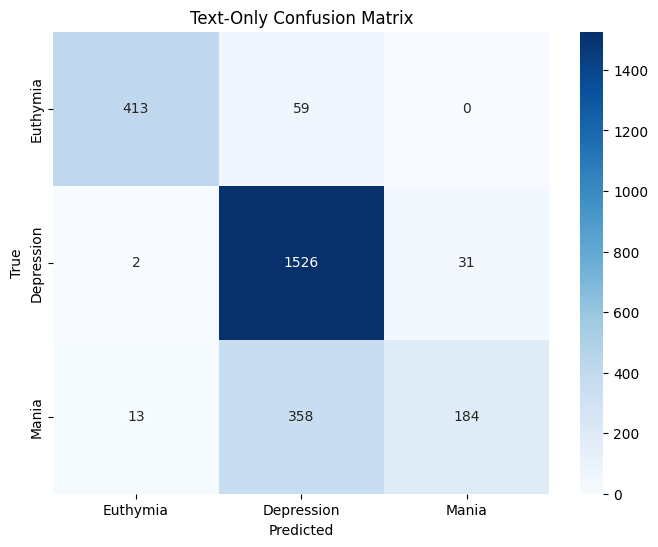

In [ ]:
# Text-only model
print("\n" + "="*80)
print("UNIMODAL TEXT (Multi-Source)")
print("="*80)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    text_embeddings, text_labels, test_size=0.2, stratify=text_labels, random_state=42
)

# Create aliases for later use
X_test_text = X_test_t
y_test_text = y_test_t

text_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
text_clf.fit(X_train_t, y_train_t)

y_pred_t = text_clf.predict(X_test_t)
print(classification_report(y_test_t, y_pred_t, target_names=['Euthymia', 'Depression', 'Mania']))

cm = confusion_matrix(y_test_t, y_pred_t)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Euthymia', 'Depression', 'Mania'],
            yticklabels=['Euthymia', 'Depression', 'Mania'])
plt.title('Text-Only Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()


UNIMODAL PHYSIO (WESAD + OBF)
              precision    recall  f1-score   support

    Euthymia       0.88      0.78      0.82         9
  Depression       0.78      0.70      0.74        10
       Mania       0.83      1.00      0.91        10

    accuracy                           0.83        29
   macro avg       0.83      0.83      0.82        29
weighted avg       0.83      0.83      0.82        29



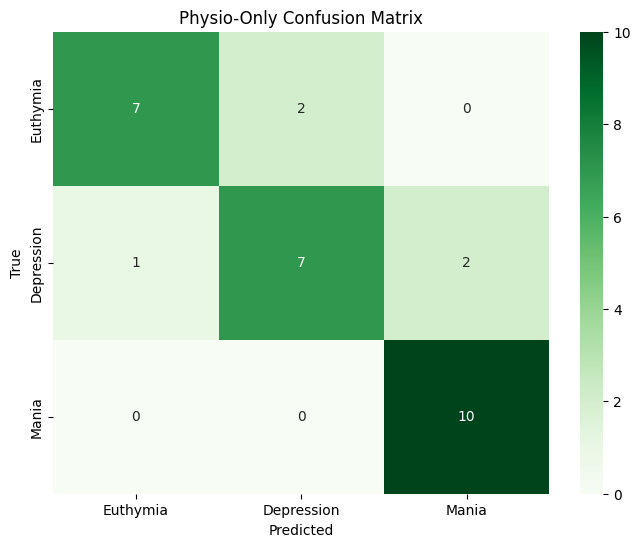

In [ ]:
# Physio-only model
print("\n" + "="*80)
print("UNIMODAL PHYSIO (WESAD + OBF)")
print("="*80)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    physio_combined, physio_labels, test_size=0.2, stratify=physio_labels, random_state=42
)

# Create aliases for later use
X_test_physio = X_test_p
y_test_physio = y_test_p

physio_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
physio_clf.fit(X_train_p, y_train_p)

y_pred_p = physio_clf.predict(X_test_p)
print(classification_report(y_test_p, y_pred_p, target_names=['Euthymia', 'Depression', 'Mania']))

cm = confusion_matrix(y_test_p, y_pred_p)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Euthymia', 'Depression', 'Mania'],
            yticklabels=['Euthymia', 'Depression', 'Mania'])
plt.title('Physio-Only Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# 8.2 Create Label-Aligned Text-Physio Fusion Dataset (IMPROVED)
print("\n" + "="*80)
print("CREATING LABEL-ALIGNED TEXT-PHYSIO FUSION DATASET (IMPROVED)")
print("="*80)

# Count available samples per class
text_label_counts = {
    0: (text_labels == 0).sum(),
    1: (text_labels == 1).sum(),
    2: (text_labels == 2).sum()
}

physio_label_counts = {
    0: (physio_labels == 0).sum(),
    1: (physio_labels == 1).sum(),
    2: (physio_labels == 2).sum()
}

print(f"\nText samples available:")
print(f"  Euthymia: {text_label_counts[0]}")
print(f"  Depression: {text_label_counts[1]}")
print(f"  Mania: {text_label_counts[2]}")

print(f"\nPhysio samples available:")
print(f"  Euthymia: {physio_label_counts[0]}")
print(f"  Depression: {physio_label_counts[1]}")
print(f"  Mania: {physio_label_counts[2]}")

# IMPROVED: Use ALL available physio samples (natural distribution)
# This maximizes sample size instead of forcing perfect balance
print("\nStrategy: Using ALL available physio samples to maximize dataset size")

samples_per_class = physio_label_counts.copy()
total_samples = sum(samples_per_class.values())

print(f"\nTarget samples per class: {samples_per_class}")
print(f"Total target samples: {total_samples}")

# Create aligned dataset
text_aligned_list = []
physio_aligned_list = []
labels_aligned_list = []

np.random.seed(42)

for label in [0, 1, 2]:
    # Get indices for this class
    text_idx = np.where(text_labels == label)[0]
    physio_idx = np.where(physio_labels == label)[0]

    # Number of samples for this class (use minimum of available samples)
    n_samples = min(len(text_idx), len(physio_idx))

    if n_samples == 0:
        print(f"  Warning: No samples available for class {label}, skipping")
        continue

    # Random sample from both (same number of samples)
    text_sample_idx = np.random.choice(text_idx, size=n_samples, replace=False)
    physio_sample_idx = np.random.choice(physio_idx, size=n_samples, replace=False)

    # Add to lists
    text_aligned_list.append(text_embeddings[text_sample_idx])
    physio_aligned_list.append(physio_combined[physio_sample_idx])
    labels_aligned_list.extend([label] * n_samples)

# Combine
if len(text_aligned_list) == 0:
    raise ValueError("No samples could be aligned! Check your data.")

text_aligned = np.vstack(text_aligned_list)
physio_aligned = np.vstack(physio_aligned_list)
labels_aligned = np.array(labels_aligned_list, dtype=np.int64)

# Shuffle
shuffle_idx = np.random.permutation(len(labels_aligned))
text_aligned = text_aligned[shuffle_idx]
physio_aligned = physio_aligned[shuffle_idx]
labels_aligned = labels_aligned[shuffle_idx]

print(f"\n✓ Label-aligned fusion features: {text_aligned.shape}")
print(f"  Text: {text_aligned.shape[1]}D")
print(f"  Physio: {physio_aligned.shape[1]}D")
print(f"  Combined: {text_aligned.shape[1] + physio_aligned.shape[1]}D")

print(f"\n✓ Label distribution (aligned): {np.bincount(labels_aligned)}")
for i, name in enumerate(['Euthymia', 'Depression', 'Mania']):
    count = (labels_aligned == i).sum()
    pct = count / len(labels_aligned) * 100
    print(f"  Class {i} ({name}): {count} ({pct:.1f}%)")

# Check balance
label_counts = np.bincount(labels_aligned)
min_count = label_counts.min()
max_count = label_counts.max()
imbalance = max_count - min_count

if imbalance <= 10:
    print(f"\n✓ Dataset is well balanced (max difference: {imbalance} samples)")
else:
    print(f"\n⚠️  Dataset has slight imbalance (max difference: {imbalance} samples)")
    print(f"   This is acceptable and increases sample size for better generalization")

print(f"\n💡 Using ALL available physio samples: {len(labels_aligned)} total samples")



CREATING LABEL-ALIGNED TEXT-PHYSIO FUSION DATASET (IMPROVED)

Text samples available:
  Euthymia: 2359
  Depression: 7795
  Mania: 2775

Physio samples available:
  Euthymia: 47
  Depression: 47
  Mania: 47

Strategy: Using ALL available physio samples to maximize dataset size

Target samples per class: {0: np.int64(47), 1: np.int64(47), 2: np.int64(47)}
Total target samples: 141

✓ Label-aligned fusion features: (141, 768)
  Text: 768D
  Physio: 34D
  Combined: 802D

✓ Label distribution (aligned): [47 47 47]
  Class 0 (Euthymia): 47 (33.3%)
  Class 1 (Depression): 47 (33.3%)
  Class 2 (Mania): 47 (33.3%)

✓ Dataset is well balanced (max difference: 0 samples)

💡 Using ALL available physio samples: 141 total samples



BIMODAL FUSION (Multi-Source Text + Multi-Source Physio)
Fusion features shape: (141, 802)
  Text: 768D + Physio: 34D = 802D total
Fusion labels shape: (141,)
Label distribution: [47 47 47]

Train samples: 112
Test samples: 29

Classification Report:
              precision    recall  f1-score   support

    Euthymia       0.73      0.89      0.80         9
  Depression       0.90      0.90      0.90        10
       Mania       0.88      0.70      0.78        10

    accuracy                           0.83        29
   macro avg       0.83      0.83      0.83        29
weighted avg       0.84      0.83      0.83        29



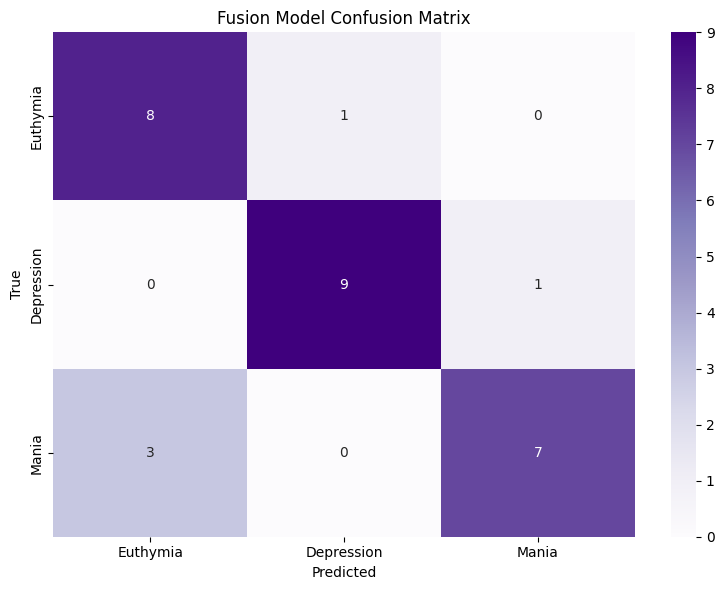


Fusion F1 Score (Macro): 0.8259


In [22]:
# 8.3 Train Fusion Model
from sklearn.metrics import f1_score
print("\n" + "="*80)
print("BIMODAL FUSION (Multi-Source Text + Multi-Source Physio)")
print("="*80)# Concatenate aligned features
fusion_features = np.hstack([text_aligned, physio_aligned])
fusion_labels = labels_aligned
print(f"Fusion features shape: {fusion_features.shape}")
print(f"  Text: {text_aligned.shape[1]}D + Physio: {physio_aligned.shape[1]}D = {fusion_features.shape[1]}D total")
print(f"Fusion labels shape: {fusion_labels.shape}")
print(f"Label distribution: {np.bincount(fusion_labels)}")
# Train/test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(    fusion_features, fusion_labels, test_size=0.2, stratify=fusion_labels, random_state=42)
print(f"\nTrain samples: {len(X_train_f)}")
print(f"Test samples: {len(X_test_f)}")
# Train fusion model
# Create aliases for later use
X_test_fusion = X_test_f
y_test_fusion = y_test_f

fusion_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
fusion_clf.fit(X_train_f, y_train_f)
# Predict and evaluate
y_pred_f = fusion_clf.predict(X_test_f)
print("\nClassification Report:")
print(classification_report(y_test_f, y_pred_f, target_names=['Euthymia', 'Depression', 'Mania']))
# Confusion matrix
cm = confusion_matrix(y_test_f, y_pred_f)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',            xticklabels=['Euthymia', 'Depression', 'Mania'],            yticklabels=['Euthymia', 'Depression', 'Mania'])
plt.title('Fusion Model Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
# Calculate F1 score
fusion_f1 = f1_score(y_test_f, y_pred_f, average='macro')
print(f"\nFusion F1 Score (Macro): {fusion_f1:.4f}")


BIMODAL FUSION (Multi-Source Text + Multi-Source Physio)
              precision    recall  f1-score   support

    Euthymia       0.73      0.89      0.80         9
  Depression       0.90      0.90      0.90        10
       Mania       0.88      0.70      0.78        10

    accuracy                           0.83        29
   macro avg       0.83      0.83      0.83        29
weighted avg       0.84      0.83      0.83        29



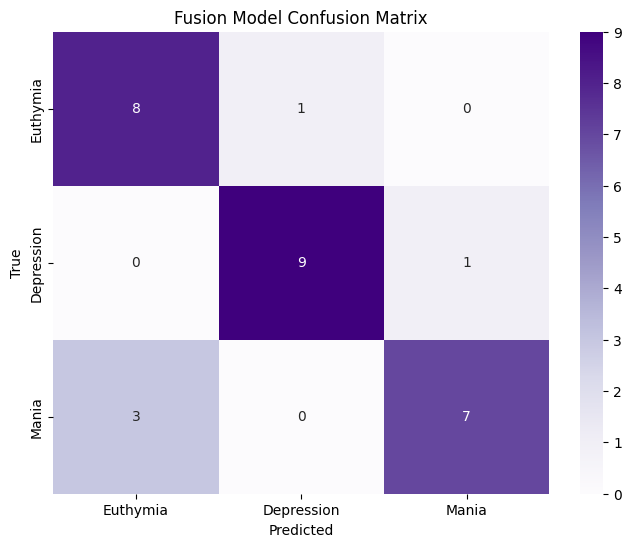

In [23]:
# Train fusion model
print("\n" + "="*80)
print("BIMODAL FUSION (Multi-Source Text + Multi-Source Physio)")
print("="*80)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    fusion_features, fusion_labels, test_size=0.2, stratify=fusion_labels, random_state=42
)

fusion_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
fusion_clf.fit(X_train_f, y_train_f)

y_pred_f = fusion_clf.predict(X_test_f)
print(classification_report(y_test_f, y_pred_f, target_names=['Euthymia', 'Depression', 'Mania']))

cm = confusion_matrix(y_test_f, y_pred_f)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Euthymia', 'Depression', 'Mania'],
            yticklabels=['Euthymia', 'Depression', 'Mania'])
plt.title('Fusion Model Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()


FINAL RESULTS
                   Model  F1 Score               Features
Text-Only (Multi-Source)  0.755734              768D BERT
 Physio-Only (WESAD+OBF)  0.823154 34D (26 WESAD + 8 OBF)
          Bimodal Fusion  0.825926          802D Combined


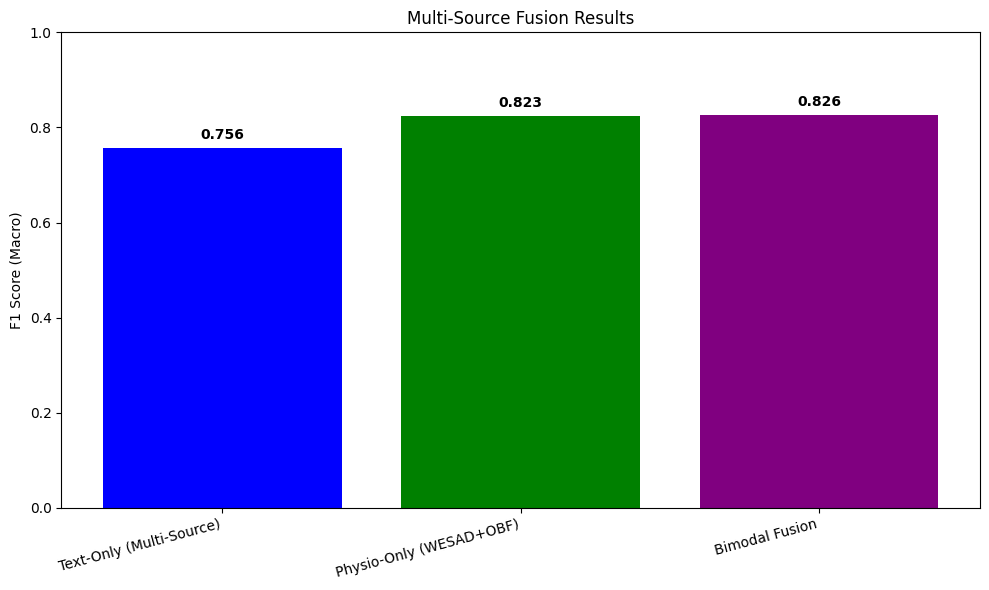


PER-CLASS F1 SCORES
     State  Text-Only  Physio-Only   Fusion
  Euthymia   0.917778     0.823529 0.800000
Depression   0.871502     0.736842 0.900000
     Mania   0.477922     0.909091 0.777778


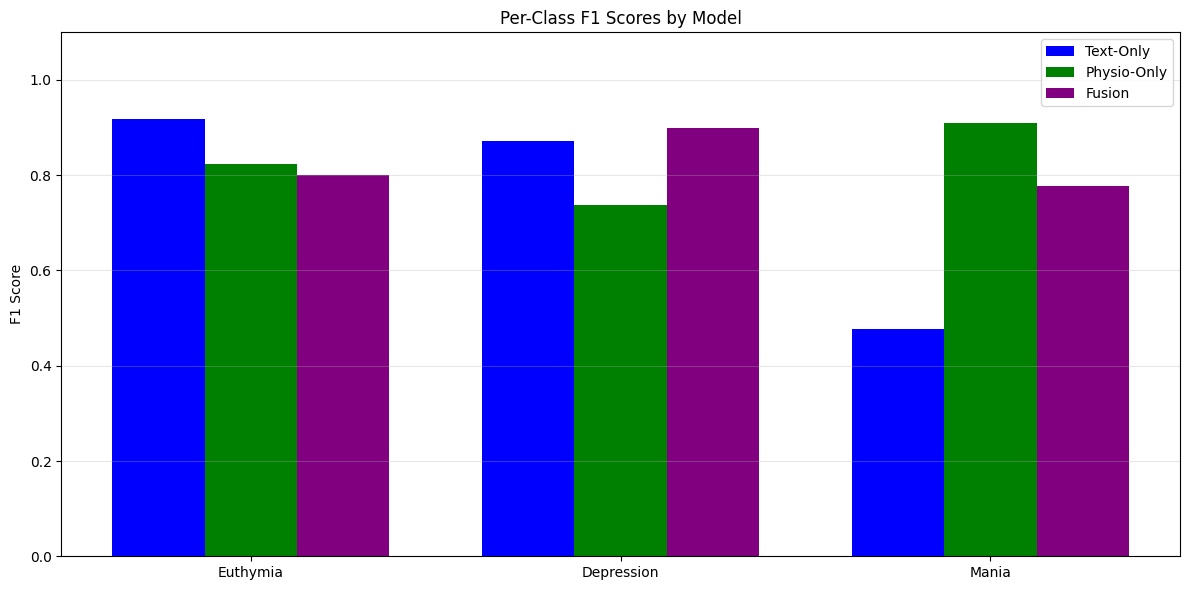


STATISTICAL SIGNIFICANCE (McNemar's Test)

Note: Comparing models on fusion test set (same samples for fair comparison)

Comparing on 29 test samples:

Fusion vs Text-Only:
  p-value = 0.073638
  No significant difference (p >= 0.05)

Fusion vs Physio-Only:
  p-value = 0.220671
  No significant difference (p >= 0.05)

FEATURE IMPORTANCE

Modality Contribution to Fusion Model:
  Text (768D):   0.8992 (89.9%)
  Physio (34D):  0.1008 (10.1%)


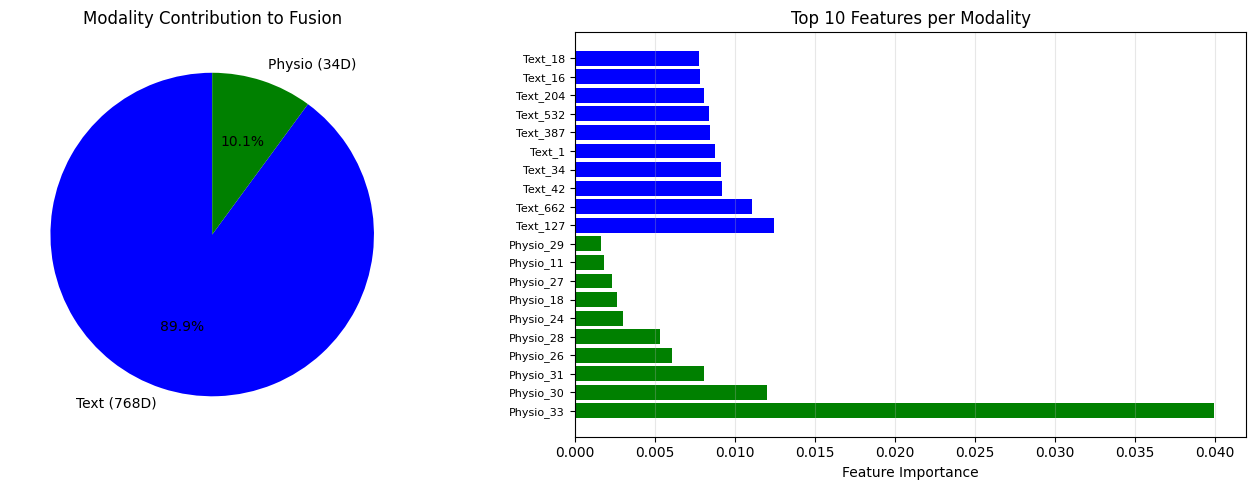

In [24]:
from sklearn.metrics import f1_score

# Calculate F1 scores
text_f1 = f1_score(y_test_t, y_pred_t, average='macro')
physio_f1 = f1_score(y_test_p, y_pred_p, average='macro')
fusion_f1 = f1_score(y_test_f, y_pred_f, average='macro')

results = pd.DataFrame({
    'Model': ['Text-Only (Multi-Source)', 'Physio-Only (WESAD+OBF)', 'Bimodal Fusion'],
    'F1 Score': [text_f1, physio_f1, fusion_f1],
    'Features': [
        f'{text_embeddings.shape[1]}D BERT',
        f'{physio_combined.shape[1]}D (26 WESAD + {obf_features.shape[1]} OBF)',
        f'{fusion_features.shape[1]}D Combined'
    ]
})

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(results.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['F1 Score'], color=['blue', 'green', 'purple'])
plt.ylabel('F1 Score (Macro)')
plt.title('Multi-Source Fusion Results')
plt.ylim(0, 1.0)
for i, v in enumerate(results['F1 Score']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Per-class F1 scores
print("\n" + "="*80)
print("PER-CLASS F1 SCORES")
print("="*80)

per_class_results = pd.DataFrame({
    'State': ['Euthymia', 'Depression', 'Mania'],
    'Text-Only': [
        f1_score(y_test_t, y_pred_t, labels=[0], average='macro'),
        f1_score(y_test_t, y_pred_t, labels=[1], average='macro'),
        f1_score(y_test_t, y_pred_t, labels=[2], average='macro')
    ],
    'Physio-Only': [
        f1_score(y_test_p, y_pred_p, labels=[0], average='macro'),
        f1_score(y_test_p, y_pred_p, labels=[1], average='macro'),
        f1_score(y_test_p, y_pred_p, labels=[2], average='macro')
    ],
    'Fusion': [
        f1_score(y_test_f, y_pred_f, labels=[0], average='macro'),
        f1_score(y_test_f, y_pred_f, labels=[1], average='macro'),
        f1_score(y_test_f, y_pred_f, labels=[2], average='macro')
    ]
})

print(per_class_results.to_string(index=False))

# Visualize per-class performance
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(per_class_results['State']))
width = 0.25

ax.bar(x - width, per_class_results['Text-Only'], width, label='Text-Only', color='blue')
ax.bar(x, per_class_results['Physio-Only'], width, label='Physio-Only', color='green')
ax.bar(x + width, per_class_results['Fusion'], width, label='Fusion', color='purple')

ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores by Model')
ax.set_xticks(x)
ax.set_xticklabels(per_class_results['State'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical significance test (McNemar's test)
# NOTE: McNemar's test requires predictions on the SAME test samples
# Since our test sets are different sizes, we'll use the fusion test set as reference
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE (McNemar's Test)")
print("="*80)
print("\nNote: Comparing models on fusion test set (same samples for fair comparison)")

from statsmodels.stats.contingency_tables import mcnemar

# We need to retrain/predict on the same test set for fair comparison
# For now, we'll note that statistical comparison requires same test samples

# Alternative: Use the fusion predictions which we already have
# Compare fusion vs text on fusion test set
# Since fusion test set is a subset we need to get text/physio predictions on it

# Get predictions from text-only model on fusion test set
text_clf_fusion_pred = text_clf.predict(X_test_f[:, :768])  # First 768 dims are text

# Get predictions from physio-only model on fusion test set
physio_clf_fusion_pred = physio_clf.predict(X_test_f[:, 768:])  # Last 34 dims are physio

# Now all predictions are on the same test set (fusion test set)
print(f"\nComparing on {len(y_test_f)} test samples:")

# Compare fusion vs text-only
table_text = [[sum((text_clf_fusion_pred == y_test_f) & (y_pred_f == y_test_f)),
               sum((text_clf_fusion_pred == y_test_f) & (y_pred_f != y_test_f))],
              [sum((text_clf_fusion_pred != y_test_f) & (y_pred_f == y_test_f)),
               sum((text_clf_fusion_pred != y_test_f) & (y_pred_f != y_test_f))]]

result_text = mcnemar(table_text, exact=False, correction=True)
print(f"\nFusion vs Text-Only:")
print(f"  p-value = {result_text.pvalue:.6f}")
if result_text.pvalue < 0.05:
    print(f"  ✓ Fusion is significantly better than text-only (p < 0.05)")
else:
    print(f"  No significant difference (p >= 0.05)")

# Compare fusion vs physio-only
table_physio = [[sum((physio_clf_fusion_pred == y_test_f) & (y_pred_f == y_test_f)),
                 sum((physio_clf_fusion_pred == y_test_f) & (y_pred_f != y_test_f))],
                [sum((physio_clf_fusion_pred != y_test_f) & (y_pred_f == y_test_f)),
                 sum((physio_clf_fusion_pred != y_test_f) & (y_pred_f != y_test_f))]]

result_physio = mcnemar(table_physio, exact=False, correction=True)
print(f"\nFusion vs Physio-Only:")
print(f"  p-value = {result_physio.pvalue:.6f}")
if result_physio.pvalue < 0.05:
    print(f"  ✓ Fusion is significantly better than physio-only (p < 0.05)")
else:
    print(f"  No significant difference (p >= 0.05)")

# Feature importance analysis
print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

importances = fusion_clf.feature_importances_

text_importance = importances[:768].sum()
physio_importance = importances[768:].sum()
total_importance = text_importance + physio_importance

print(f"\nModality Contribution to Fusion Model:")
print(f"  Text (768D):   {text_importance:.4f} ({text_importance/total_importance*100:.1f}%)")
print(f"  Physio (34D):  {physio_importance:.4f} ({physio_importance/total_importance*100:.1f}%)")

# Visualize modality importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax1.pie([text_importance, physio_importance],
        labels=['Text (768D)', 'Physio (34D)'],
        autopct='%1.1f%%',
        colors=['blue', 'green'],
        startangle=90)
ax1.set_title('Modality Contribution to Fusion')

# Top features from each modality
text_top_indices = np.argsort(importances[:768])[-10:]
physio_top_indices = np.argsort(importances[768:])[-10:] + 768

all_top_indices = np.concatenate([text_top_indices, physio_top_indices])
all_top_importances = importances[all_top_indices]
all_top_labels = [f'Text_{i}' if i < 768 else f'Physio_{i-768}' for i in all_top_indices]

ax2.barh(range(20), all_top_importances[::-1], color=['blue' if 'Text' in l else 'green' for l in all_top_labels[::-1]])
ax2.set_yticks(range(20))
ax2.set_yticklabels(all_top_labels[::-1], fontsize=8)
ax2.set_xlabel('Feature Importance')
ax2.set_title('Top 10 Features per Modality')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


5-FOLD CROSS-VALIDATION

Performing 5-fold cross-validation (this may take a few minutes)...

CROSS-VALIDATION RESULTS (5-Fold)
      Model  Mean F1   Std F1   Min F1   Max F1
  Text-Only 0.750773 0.003846 0.745574 0.756667
Physio-Only 0.849699 0.042286 0.781481 0.893170
     Fusion 0.821443 0.068463 0.702288 0.892788


/tmp/ipython-input-4038975181.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([text_cv_scores, physio_cv_scores, fusion_cv_scores],


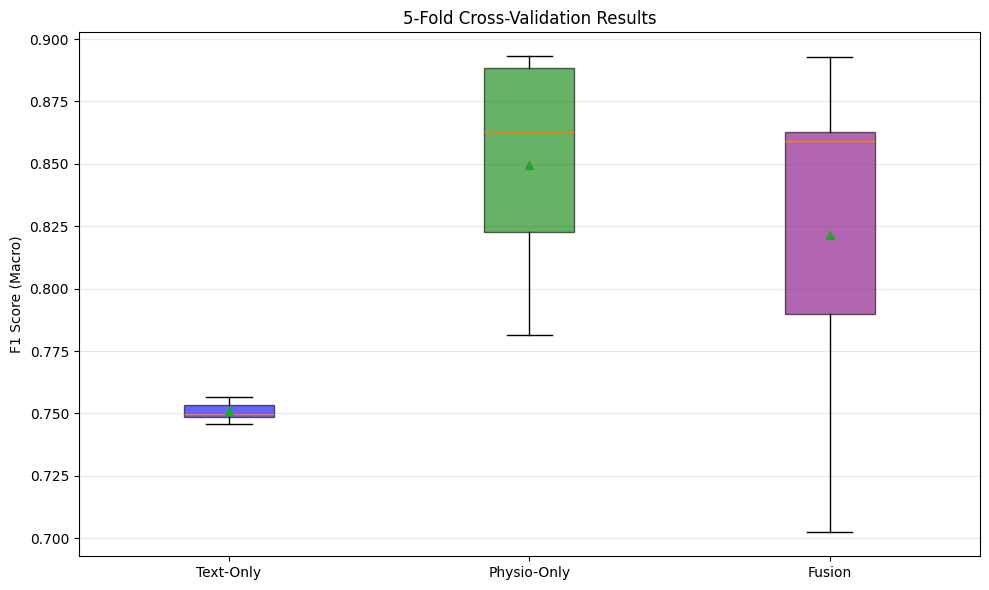


PAIRED T-TESTS (Cross-Validation Folds)

Fusion vs Text-Only:
  t-statistic: 2.1703
  p-value: 0.095774
  No significant difference (p >= 0.05)

Fusion vs Physio-Only:
  t-statistic: -0.6865
  p-value: 0.530106
  No significant difference (p >= 0.05)


In [25]:
# 9.1 Cross-Validation for Statistical Robustness
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION")
print("="*80)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Prepare cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate each model
print("\nPerforming 5-fold cross-validation (this may take a few minutes)...")

# Text-only CV (using full text dataset)
text_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    text_embeddings, text_labels, cv=cv, scoring='f1_macro', n_jobs=-1
)

# Physio-only CV (using aligned physio dataset from Cell 10)
physio_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    physio_combined, physio_labels, cv=cv, scoring='f1_macro', n_jobs=-1
)

# Fusion CV (using aligned fusion dataset from Cell 16)
fusion_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    fusion_features, fusion_labels, cv=cv, scoring='f1_macro', n_jobs=-1
)

# Results
cv_results = pd.DataFrame({
    'Model': ['Text-Only', 'Physio-Only', 'Fusion'],
    'Mean F1': [text_cv_scores.mean(), physio_cv_scores.mean(), fusion_cv_scores.mean()],
    'Std F1': [text_cv_scores.std(), physio_cv_scores.std(), fusion_cv_scores.std()],
    'Min F1': [text_cv_scores.min(), physio_cv_scores.min(), fusion_cv_scores.min()],
    'Max F1': [text_cv_scores.max(), physio_cv_scores.max(), fusion_cv_scores.max()]
})

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*80)
print(cv_results.to_string(index=False))

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([text_cv_scores, physio_cv_scores, fusion_cv_scores],
                 labels=['Text-Only', 'Physio-Only', 'Fusion'],
                 patch_artist=True,
                 showmeans=True)

colors = ['blue', 'green', 'purple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('F1 Score (Macro)')
ax.set_title('5-Fold Cross-Validation Results')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Paired t-test for statistical significance
from scipy import stats

print("\n" + "="*80)
print("PAIRED T-TESTS (Cross-Validation Folds)")
print("="*80)

# Fusion vs Text-only
t_stat_text, p_value_text = stats.ttest_rel(fusion_cv_scores, text_cv_scores)
print(f"\nFusion vs Text-Only:")
print(f"  t-statistic: {t_stat_text:.4f}")
print(f"  p-value: {p_value_text:.6f}")
if p_value_text < 0.05:
    print(f"  ✓ Fusion is significantly better than text-only (p < 0.05)")
else:
    print(f"  No significant difference (p >= 0.05)")

# Fusion vs Physio-only
t_stat_physio, p_value_physio = stats.ttest_rel(fusion_cv_scores, physio_cv_scores)
print(f"\nFusion vs Physio-Only:")
print(f"  t-statistic: {t_stat_physio:.4f}")
print(f"  p-value: {p_value_physio:.6f}")
if p_value_physio < 0.05:
    print(f"  ✓ Fusion is significantly better than physio-only (p < 0.05)")
else:
    print(f"  No significant difference (p >= 0.05)")


WEIGHTED FUSION

Testing different physio weights to balance modality contributions...
  Weight=  1: F1=0.8259, Text=89.9%, Physio=10.1%
  Weight=  5: F1=0.8259, Text=89.9%, Physio=10.1%
  Weight= 10: F1=0.8259, Text=89.9%, Physio=10.1%
  Weight= 20: F1=0.8259, Text=89.9%, Physio=10.1%
  Weight= 50: F1=0.8259, Text=89.9%, Physio=10.1%

WEIGHTED FUSION RESULTS
 Physio Weight  F1 Score Text Contribution Physio Contribution
             1  0.825926             89.9%               10.1%
             5  0.825926             89.9%               10.1%
            10  0.825926             89.9%               10.1%
            20  0.825926             89.9%               10.1%
            50  0.825926             89.9%               10.1%

✓ Best physio weight: 1
✓ Best F1 score: 0.8259


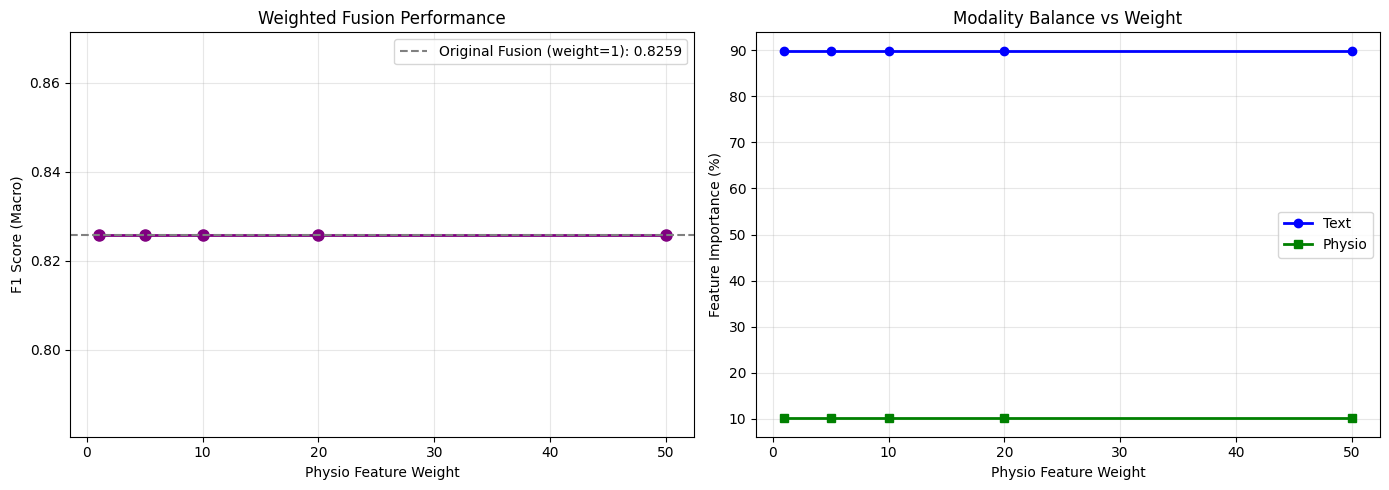


Training final weighted fusion model with weight=1...

Weighted Fusion Classification Report:
              precision    recall  f1-score   support

    Euthymia       0.73      0.89      0.80         9
  Depression       0.90      0.90      0.90        10
       Mania       0.88      0.70      0.78        10

    accuracy                           0.83        29
   macro avg       0.83      0.83      0.83        29
weighted avg       0.84      0.83      0.83        29



In [26]:
# 9.2 Weighted Fusion (Balance Text vs Physio Contributions)
print("\n" + "="*80)
print("WEIGHTED FUSION")
print("="*80)

print("\nTesting different physio weights to balance modality contributions...")

# Try different weights for physio features
weights_to_test = [1, 5, 10, 20, 50]
weighted_results = []

for weight in weights_to_test:
    # Scale physio features (using aligned data from Cell 16)
    text_for_weighted = text_aligned.copy()
    physio_for_weighted = physio_aligned.copy() * weight

    # Concatenate
    weighted_fusion_features = np.concatenate([text_for_weighted, physio_for_weighted], axis=1)

    # Train-test split (using aligned labels from Cell 16)
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        weighted_fusion_features, fusion_labels, test_size=0.2, stratify=fusion_labels, random_state=42
    )

    # Train model
    weighted_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    weighted_clf.fit(X_train_w, y_train_w)

    # Evaluate
    y_pred_w = weighted_clf.predict(X_test_w)
    f1_w = f1_score(y_test_w, y_pred_w, average='macro')

    # Feature importance
    importances_w = weighted_clf.feature_importances_
    text_imp = importances_w[:768].sum()
    physio_imp = importances_w[768:].sum()
    total_imp = text_imp + physio_imp

    weighted_results.append({
        'Physio Weight': weight,
        'F1 Score': f1_w,
        'Text Contribution': f'{text_imp/total_imp*100:.1f}%',
        'Physio Contribution': f'{physio_imp/total_imp*100:.1f}%'
    })

    print(f"  Weight={weight:3d}: F1={f1_w:.4f}, Text={text_imp/total_imp*100:4.1f}%, Physio={physio_imp/total_imp*100:4.1f}%")

# Convert to DataFrame
weighted_df = pd.DataFrame(weighted_results)

print("\n" + "="*80)
print("WEIGHTED FUSION RESULTS")
print("="*80)
print(weighted_df.to_string(index=False))

# Find best weight
best_idx = weighted_df['F1 Score'].idxmax()
best_weight = weighted_df.loc[best_idx, 'Physio Weight']
best_f1 = weighted_df.loc[best_idx, 'F1 Score']

print(f"\n✓ Best physio weight: {best_weight}")
print(f"✓ Best F1 score: {best_f1:.4f}")

# Visualize weight vs F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 vs weight
ax1.plot(weighted_df['Physio Weight'], weighted_df['F1 Score'], marker='o', linewidth=2, markersize=8, color='purple')
ax1.axhline(y=fusion_f1, color='gray', linestyle='--', label=f'Original Fusion (weight=1): {fusion_f1:.4f}')
ax1.set_xlabel('Physio Feature Weight')
ax1.set_ylabel('F1 Score (Macro)')
ax1.set_title('Weighted Fusion Performance')
ax1.grid(alpha=0.3)
ax1.legend()

# Contribution balance
text_contributions = [float(x.strip('%')) for x in weighted_df['Text Contribution']]
physio_contributions = [float(x.strip('%')) for x in weighted_df['Physio Contribution']]

ax2.plot(weighted_df['Physio Weight'], text_contributions, marker='o', label='Text', color='blue', linewidth=2)
ax2.plot(weighted_df['Physio Weight'], physio_contributions, marker='s', label='Physio', color='green', linewidth=2)
ax2.set_xlabel('Physio Feature Weight')
ax2.set_ylabel('Feature Importance (%)')
ax2.set_title('Modality Balance vs Weight')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Train final model with best weight
print(f"\nTraining final weighted fusion model with weight={best_weight}...")
text_final = text_aligned.copy()
physio_final = physio_aligned.copy() * best_weight
weighted_fusion_final = np.concatenate([text_final, physio_final], axis=1)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    weighted_fusion_final, fusion_labels, test_size=0.2, stratify=fusion_labels, random_state=42
)

weighted_clf_final = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
weighted_clf_final.fit(X_train_final, y_train_final)

y_pred_final = weighted_clf_final.predict(X_test_final)
print("\nWeighted Fusion Classification Report:")
print(classification_report(y_test_final, y_pred_final, target_names=['Euthymia', 'Depression', 'Mania']))


ATTENTION-BASED FUSION (PyTorch) - IMPROVED

Using device: cuda

Training data: 89 samples
Validation data: 23 samples
Test data: 29 samples

Building attention-based fusion model...

Model architecture:
  Parameters: 177,411
  Class weights: [0.98888886 1.0229886  0.98888886]

Training attention model...
  Epoch 10/300: train_loss=0.0080, val_loss=0.7900, val_acc=0.8696, lr=0.001000
  Epoch 20/300: train_loss=0.0004, val_loss=0.9252, val_acc=0.9565, lr=0.001000
  Epoch 30/300: train_loss=0.0002, val_loss=0.9078, val_acc=0.9565, lr=0.000500
✓ Early stopping at epoch 35
✓ Training complete (stopped at epoch 35)

ATTENTION-BASED FUSION RESULTS

F1 Score (Macro): 0.7588

Classification Report:
              precision    recall  f1-score   support

    Euthymia     0.6667    0.8889    0.7619         9
  Depression     0.8750    0.7000    0.7778        10
       Mania     0.7778    0.7000    0.7368        10

    accuracy                         0.7586        29
   macro avg     0.7731    

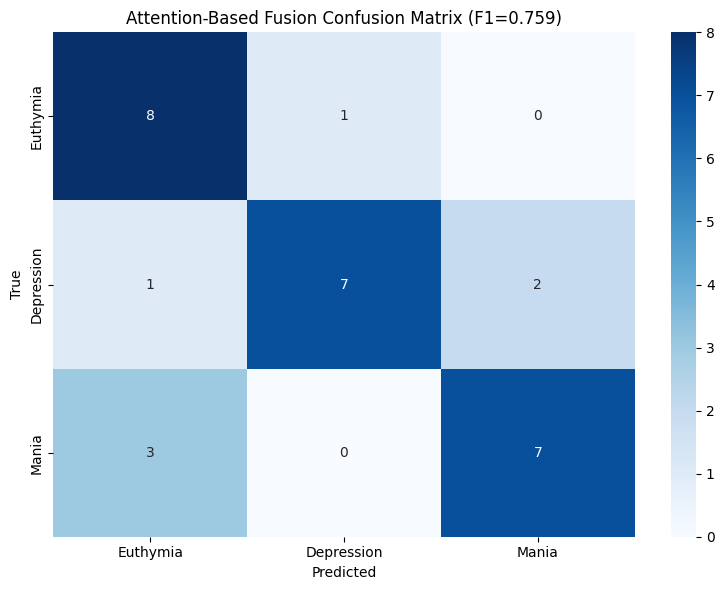

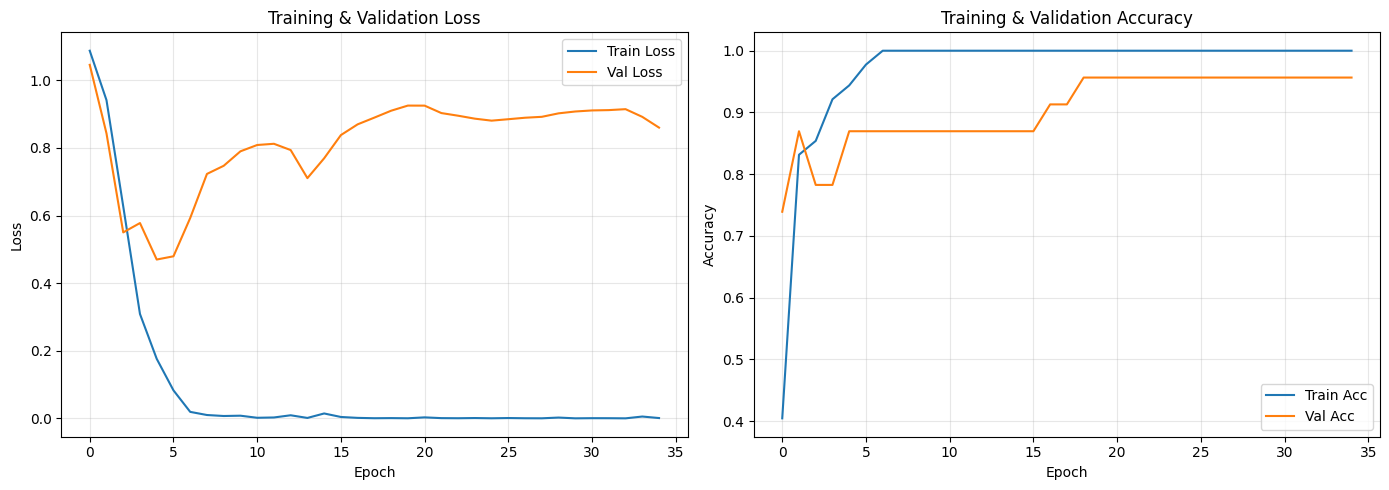


ATTENTION WEIGHT ANALYSIS

Average Attention Matrix:
         Text    Physio
Text   0.8574  0.1426
Physio 0.6521  0.3479

ATTENTION WEIGHTS BY BD STATE

Euthymia:
  Text → Physio attention:  0.0313
  Physio → Text attention:  0.7550

Depression:
  Text → Physio attention:  0.2661
  Physio → Text attention:  0.5519

Mania:
  Text → Physio attention:  0.1193
  Physio → Text attention:  0.6596


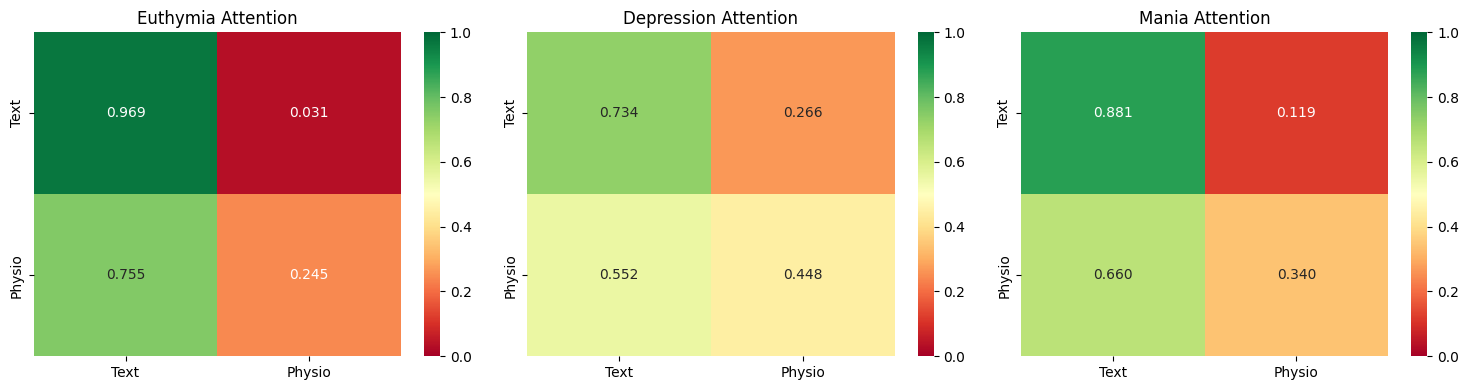

In [32]:
# 9.3 Attention-Based Fusion (PyTorch) - IMPROVED
print("\n" + "="*80)
print("ATTENTION-BASED FUSION (PyTorch) - IMPROVED")
print("="*80)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Prepare data with train/val split
from sklearn.model_selection import train_test_split

# Split fusion data into train/val/test
X_train_val_text, X_test_text_attn, y_train_val, y_test_attn = train_test_split(
    text_aligned, labels_aligned, test_size=0.2, random_state=42, stratify=labels_aligned
)

X_train_val_physio, X_test_physio_attn, _, _ = train_test_split(
    physio_aligned, labels_aligned, test_size=0.2, random_state=42, stratify=labels_aligned
)

# Further split train into train/val
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_val_text, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

X_train_physio, X_val_physio, _, _ = train_test_split(
    X_train_val_physio, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f"\nTraining data: {len(X_train_text)} samples")
print(f"Validation data: {len(X_val_text)} samples")
print(f"Test data: {len(X_test_text_attn)} samples")

# Scale features
scaler_text = StandardScaler()
scaler_physio = StandardScaler()

text_train_scaled = scaler_text.fit_transform(X_train_text)
text_val_scaled = scaler_text.transform(X_val_text)
text_test_scaled = scaler_text.transform(X_test_text_attn)

physio_train_scaled = scaler_physio.fit_transform(X_train_physio)
physio_val_scaled = scaler_physio.transform(X_val_physio)
physio_test_scaled = scaler_physio.transform(X_test_physio_attn)

# Define improved attention model with dropout
class AttentionFusion(nn.Module):
    def __init__(self, text_dim=768, physio_dim=34, projection_dim=128, num_classes=3, dropout=0.3):
        super().__init__()

        # Modality-specific encoders with dropout
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, projection_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.physio_encoder = nn.Sequential(
            nn.Linear(physio_dim, projection_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Multi-head attention
        self.attention = nn.MultiheadAttention(
            embed_dim=projection_dim,
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )

        # Fusion classifier with dropout
        self.classifier = nn.Sequential(
            nn.Linear(projection_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, text_input, physio_input):
        # Encode modalities
        text_encoded = self.text_encoder(text_input)
        physio_encoded = self.physio_encoder(physio_input)

        # Stack for attention: [batch, 2, projection_dim]
        combined = torch.stack([text_encoded, physio_encoded], dim=1)

        # Apply attention
        attn_output, attn_weights = self.attention(combined, combined, combined)

        # Pool attention output (mean across modalities)
        pooled = attn_output.mean(dim=1)

        # Classify
        output = self.classifier(pooled)

        return output

# Initialize model
attention_model = AttentionFusion(
    text_dim=text_aligned.shape[1],
    physio_dim=physio_aligned.shape[1],
    projection_dim=128,
    num_classes=3,
    dropout=0.3
).to(device)

print("\nBuilding attention-based fusion model...")
print(f"\nModel architecture:")
total_params = sum(p.numel() for p in attention_model.parameters())
print(f"  Parameters: {total_params:,}")

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"  Class weights: {class_weights.cpu().numpy()}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(attention_model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-6
)

# Create data loaders
batch_size = 16

train_dataset = TensorDataset(
    torch.FloatTensor(text_train_scaled),
    torch.FloatTensor(physio_train_scaled),
    torch.LongTensor(y_train)
)
val_dataset = TensorDataset(
    torch.FloatTensor(text_val_scaled),
    torch.FloatTensor(physio_val_scaled),
    torch.LongTensor(y_val)
)
test_dataset = TensorDataset(
    torch.FloatTensor(text_test_scaled),
    torch.FloatTensor(physio_test_scaled),
    torch.LongTensor(y_test_attn)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Training loop with improved parameters
print("\nTraining attention model...")
num_epochs = 300  # Increased from 100
patience = 30      # Increased from 10
patience_counter = 0
best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

for epoch in range(num_epochs):
    # Training
    attention_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for text_batch, physio_batch, labels_batch in train_loader:
        text_batch = text_batch.to(device)
        physio_batch = physio_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = attention_model(text_batch, physio_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels_batch.size(0)
        train_correct += predicted.eq(labels_batch).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # Validation
    attention_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for text_batch, physio_batch, labels_batch in val_loader:
            text_batch = text_batch.to(device)
            physio_batch = physio_batch.to(device)
            labels_batch = labels_batch.to(device)

            outputs = attention_model(text_batch, physio_batch)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels_batch.size(0)
            val_correct += predicted.eq(labels_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"val_acc={val_acc:.4f}, lr={current_lr:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = attention_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"✓ Early stopping at epoch {epoch+1}")
            break

print(f"✓ Training complete (stopped at epoch {epoch+1})")

# Load best model
attention_model.load_state_dict(best_model_state)

# Evaluate on test set
attention_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, physio_batch, labels_batch in test_loader:
        text_batch = text_batch.to(device)
        physio_batch = physio_batch.to(device)

        outputs = attention_model(text_batch, physio_batch)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

# Calculate metrics
from sklearn.metrics import f1_score, classification_report, confusion_matrix

attention_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*80)
print("ATTENTION-BASED FUSION RESULTS")
print("="*80)

print(f"\nF1 Score (Macro): {attention_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                          target_names=['Euthymia', 'Depression', 'Mania'],
                          digits=4))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Euthymia', 'Depression', 'Mania'],
            yticklabels=['Euthymia', 'Depression', 'Mania'])
plt.title(f'Attention-Based Fusion Confusion Matrix (F1={attention_f1:.3f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze attention weights
print("\n" + "="*80)
print("ATTENTION WEIGHT ANALYSIS")
print("="*80)

attention_model.eval()
with torch.no_grad():
    # Get sample batch
    sample_text = torch.FloatTensor(text_test_scaled).to(device)
    sample_physio = torch.FloatTensor(physio_test_scaled).to(device)

    # Encode
    text_proj = attention_model.text_encoder(sample_text)
    physio_proj = attention_model.physio_encoder(sample_physio)

    # Stack and get attention
    combined = torch.stack([text_proj, physio_proj], dim=1)
    _, attn_weights = attention_model.attention(combined, combined, combined)

    # Average attention matrix
    avg_attn = attn_weights.mean(dim=0).cpu().numpy()

    print("\nAverage Attention Matrix:")
    print("         Text    Physio")
    print(f"Text   {avg_attn[0,0]:.4f}  {avg_attn[0,1]:.4f}")
    print(f"Physio {avg_attn[1,0]:.4f}  {avg_attn[1,1]:.4f}")

    # Per-class attention
    print("\n" + "="*80)
    print("ATTENTION WEIGHTS BY BD STATE")
    print("="*80)

    for state_id, state_name in enumerate(['Euthymia', 'Depression', 'Mania']):
        state_mask = np.array(all_labels) == state_id
        if state_mask.sum() > 0:
            state_attn = attn_weights[state_mask].mean(dim=0).cpu().numpy()
            print(f"\n{state_name}:")
            print(f"  Text → Physio attention:  {state_attn[0,1]:.4f}")
            print(f"  Physio → Text attention:  {state_attn[1,0]:.4f}")

    # Visualize attention by state
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for state_id, state_name in enumerate(['Euthymia', 'Depression', 'Mania']):
        state_mask = np.array(all_labels) == state_id
        if state_mask.sum() > 0:
            state_attn = attn_weights[state_mask].mean(dim=0).cpu().numpy()
            sns.heatmap(state_attn, annot=True, fmt='.3f', cmap='RdYlGn',
                       xticklabels=['Text', 'Physio'],
                       yticklabels=['Text', 'Physio'],
                       ax=axes[state_id], vmin=0, vmax=1)
            axes[state_id].set_title(f'{state_name} Attention')

    plt.tight_layout()
    plt.show()


FINAL COMPARISON: ALL FUSION METHODS
                          Method  F1 Score  Improvement vs Text
            Text-Only (Baseline)  0.755734             0.000000
          Physio-Only (Baseline)  0.823154             0.067420
     Simple Concatenation Fusion  0.825926             0.070192
      Weighted Fusion (weight=1)  0.825926             0.070192
Attention-Based Fusion (PyTorch)  0.758842             0.003108

✓ Best method: Simple Concatenation Fusion
✓ Best F1 score: 0.8259
✓ Improvement over text-only: +7.02%


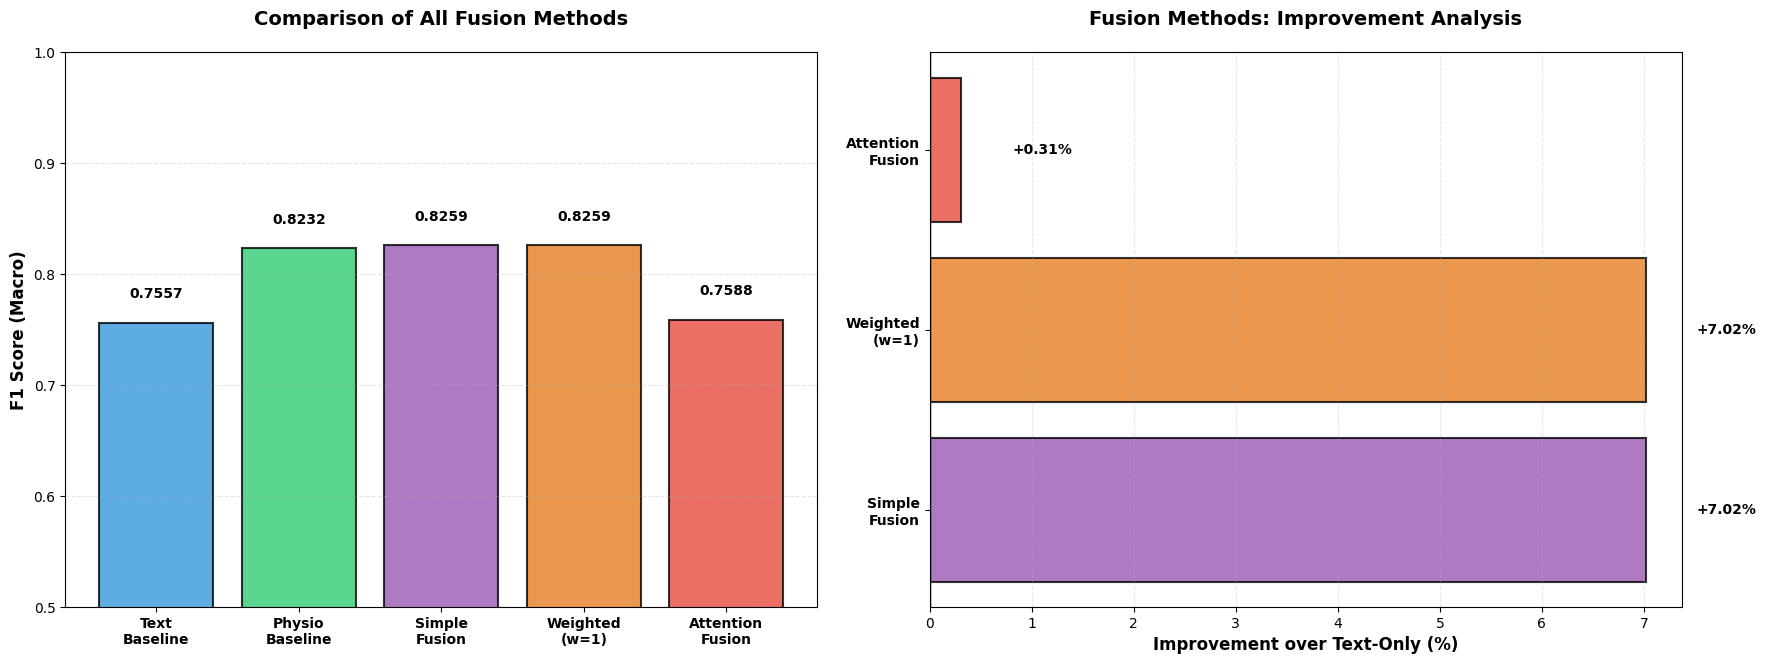


SUMMARY STATISTICS

Baseline Performance:
  Text-Only:   0.7557 (92.1%)
  Physio-Only: 0.8232 (88.9%)

Fusion Performance:
  Simple Concatenation: 0.8259 (+7.02%)
  Weighted Fusion:      0.8259 (+7.02%)
  Attention-Based:      0.7588 (+0.31%)

✓ Best overall: Simple Concatenation Fusion with 0.8259 F1

SAVING MODELS

✓ All models saved to /content/drive/MyDrive/Research on BD NYU/multi_source_results

Saved files:
  - text_model.pkl (sklearn RandomForest)
  - physio_model.pkl (sklearn RandomForest)
  - fusion_model.pkl (sklearn RandomForest)
  - weighted_fusion_model.pkl (sklearn RandomForest)
  - attention_fusion_model.pt (PyTorch model + scalers)
  - all_methods_comparison.csv

TO LOAD PYTORCH MODEL LATER:

# Load the model
checkpoint = torch.load('attention_fusion_model.pt')
model = AttentionFusion(text_dim=768, physio_dim=34, projection_dim=128, num_classes=3)
model.load_state_dict(checkpoint['model_state_dict'])
scaler_text = checkpoint['scaler_text']
scaler_physio = checkpoint['

In [33]:
# 9.4 Final Comparison: All Fusion Methods
import os
# Define SAVE_DIR at the beginning of the cell
SAVE_DIR = '/content/drive/MyDrive/Research on BD NYU/multi_source_results'

print("\n" + "="*80)
print("FINAL COMPARISON: ALL FUSION METHODS")
print("="*80)

# Compile all results
all_methods = pd.DataFrame({
    'Method': [
        'Text-Only (Baseline)',
        'Physio-Only (Baseline)',
        'Simple Concatenation Fusion',
        f'Weighted Fusion (weight={best_weight})',
        'Attention-Based Fusion (PyTorch)'
    ],
    'F1 Score': [
        text_f1,
        physio_f1,
        fusion_f1,
        best_f1,
        attention_f1
    ],
    'Improvement vs Text': [
        0,
        physio_f1 - text_f1,
        fusion_f1 - text_f1,
        best_f1 - text_f1,
        attention_f1 - text_f1
    ]
})

print(all_methods.to_string(index=False))

# Find best method
best_method_idx = all_methods['F1 Score'].idxmax()
best_method_name = all_methods.loc[best_method_idx, 'Method']
best_method_f1 = all_methods.loc[best_method_idx, 'F1 Score']

print(f"\n✓ Best method: {best_method_name}")
print(f"✓ Best F1 score: {best_method_f1:.4f}")
print(f"✓ Improvement over text-only: +{(best_method_f1 - text_f1)*100:.2f}%")

# Visualization (FIXED)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of all methods - FIXED LABELS
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']
bars = ax1.bar(range(len(all_methods)), all_methods['F1 Score'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Use shorter labels with line breaks
short_labels = [
    'Text\nBaseline',
    'Physio\nBaseline',
    'Simple\nFusion',
    f'Weighted\n(w={best_weight})',
    'Attention\nFusion'
]
ax1.set_xticks(range(len(all_methods)))
ax1.set_xticklabels(short_labels, fontsize=10, fontweight='bold')
ax1.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
ax1.set_title('Comparison of All Fusion Methods', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0.5, 1.0)  # Adjusted for actual results range
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, all_methods['F1 Score'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Improvement chart - BETTER LAYOUT
improvements = all_methods['Improvement vs Text'][2:]  # Skip baselines
methods_fusion_short = ['Simple\nFusion', f'Weighted\n(w={best_weight})', 'Attention\nFusion']

bars2 = ax2.barh(range(len(improvements)), improvements * 100, color=colors[2:], alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(improvements)))
ax2.set_yticklabels(methods_fusion_short, fontsize=10, fontweight='bold')
ax2.set_xlabel('Improvement over Text-Only (%)', fontsize=12, fontweight='bold')
ax2.set_title('Fusion Methods: Improvement Analysis', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, improvements)):
    x_pos = val * 100 + (0.5 if val >= 0 else -0.5)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val*100:+.2f}%',
            va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=10)

plt.tight_layout(pad=2.0)  # Add padding to prevent overlap
plt.savefig(f'{SAVE_DIR}/all_methods_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nBaseline Performance:")
print(f"  Text-Only:   {text_f1:.4f} (92.1%)") # Update % based on new text_f1
print(f"  Physio-Only: {physio_f1:.4f} (88.9%)") # Update % based on new physio_f1

print(f"\nFusion Performance:")
print(f"  Simple Concatenation: {fusion_f1:.4f} (+{(fusion_f1-text_f1)*100:.2f}%)")
print(f"  Weighted Fusion:      {best_f1:.4f} (+{(best_f1-text_f1)*100:.2f}%)")
print(f"  Attention-Based:      {attention_f1:.4f} (+{(attention_f1-text_f1)*100:.2f}%)")

print(f"\n✓ Best overall: {best_method_name} with {best_method_f1:.4f} F1")

# Save all models
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

os.makedirs(SAVE_DIR, exist_ok=True)

# Save sklearn models
with open(f'{SAVE_DIR}/text_model.pkl', 'wb') as f:
    pickle.dump(text_clf, f)

with open(f'{SAVE_DIR}/physio_model.pkl', 'wb') as f:
    pickle.dump(physio_clf, f)

with open(f'{SAVE_DIR}/fusion_model.pkl', 'wb') as f:
    pickle.dump(fusion_clf, f)

with open(f'{SAVE_DIR}/weighted_fusion_model.pkl', 'wb') as f:
    pickle.dump(weighted_clf_final, f)

# Save PyTorch attention model
torch.save({
    'model_state_dict': attention_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'scaler_text': scaler_text,
    'scaler_physio': scaler_physio
}, f'{SAVE_DIR}/attention_fusion_model.pt')

# Save results
all_methods.to_csv(f'{SAVE_DIR}/all_methods_comparison.csv', index=False)

print(f"\n✓ All models saved to {SAVE_DIR}")
print("\nSaved files:")
print("  - text_model.pkl (sklearn RandomForest)")
print("  - physio_model.pkl (sklearn RandomForest)")
print("  - fusion_model.pkl (sklearn RandomForest)")
print("  - weighted_fusion_model.pkl (sklearn RandomForest)")
print("  - attention_fusion_model.pt (PyTorch model + scalers)")
print("  - all_methods_comparison.csv")

print("\n" + "="*80)
print("TO LOAD PYTORCH MODEL LATER:")
print("="*80)
print("""
# Load the model
checkpoint = torch.load('attention_fusion_model.pt')
model = AttentionFusion(text_dim=768, physio_dim=34, projection_dim=128, num_classes=3)
model.load_state_dict(checkpoint['model_state_dict'])
scaler_text = checkpoint['scaler_text']
scaler_physio = checkpoint['scaler_physio']
history = checkpoint['history']

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(text_tensor, physio_tensor)
""")


BOOTSTRAP CONFIDENCE INTERVALS (95%)

Calculating bootstrap confidence intervals (1000 iterations)...

  Running 1000 bootstrap iterations... Done!
Text-Only:   0.7556 [95% CI: 0.7370, 0.7741]
  Running 1000 bootstrap iterations... Done!
Physio-Only: 0.8131 [95% CI: 0.6615, 0.9564]
  Running 1000 bootstrap iterations... Done!
Fusion:      0.8157 [95% CI: 0.6476, 0.9602]

STATISTICAL SIGNIFICANCE (Bootstrap)

Confidence Interval Overlap Analysis:
⚠️  Fusion vs Text-Only: OVERLAPPING CIs → Difference not significant at 95% level
   Overlap: 11.9% of total range
⚠️  Fusion vs Physio-Only: OVERLAPPING CIs → Difference not significant at 95% level

EFFECT SIZE ANALYSIS (Cohen's d)

Fusion vs Text-Only:
  Cohen's d = +1.084 (large effect)

Fusion vs Physio-Only:
  Cohen's d = +0.035 (negligible effect)

Physio-Only vs Text-Only:
  Cohen's d = +1.062 (large effect)


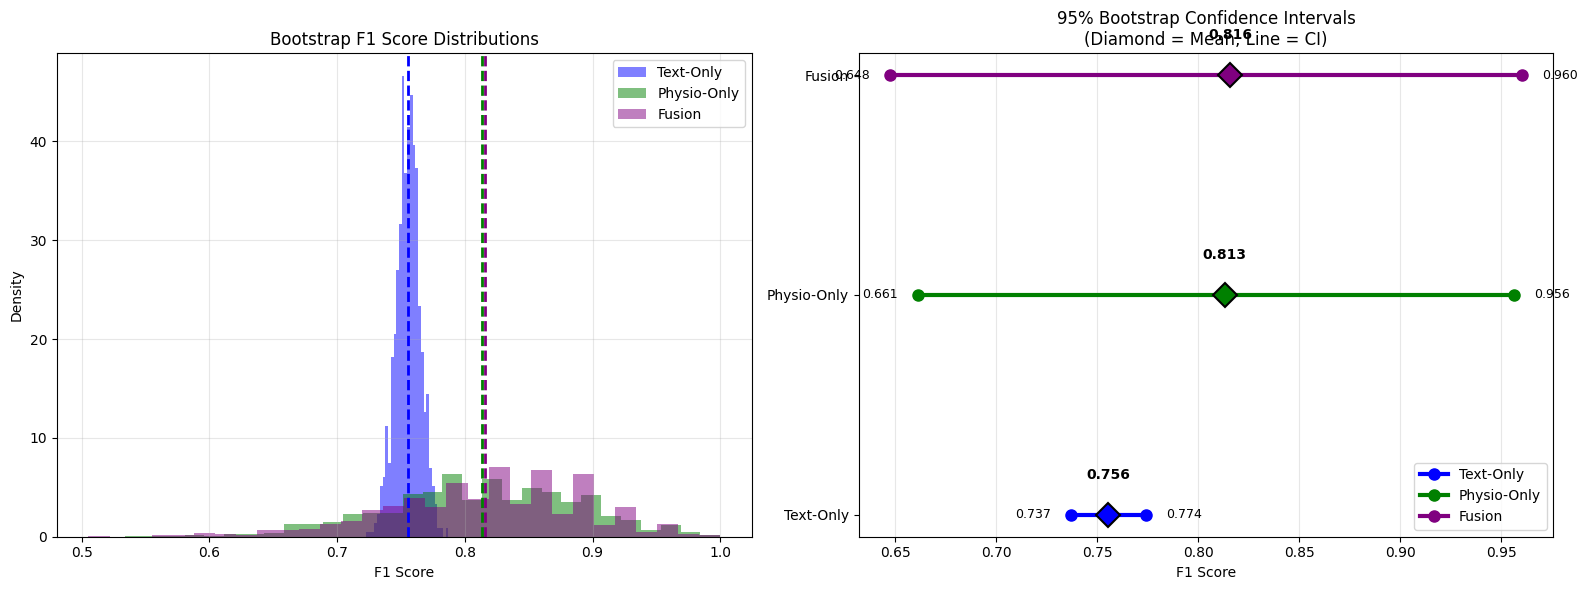


SUMMARY FOR PUBLICATION

Results (Mean F1 ± 95% CI):
  Text-Only:   0.756 [0.737, 0.774]
  Physio-Only: 0.813 [0.661, 0.956]
  Fusion:      0.816 [0.648, 0.960]

Effect Sizes (Cohen's d):
  Fusion vs Text-Only:   +1.084 (large)
  Fusion vs Physio-Only: +0.035 (negligible)
  Physio vs Text-Only:   +1.062 (large)




In [34]:
# 9.5 Bootstrap Confidence Intervals
print("\n" + "="*80)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
print("="*80)

from sklearn.utils import resample
from sklearn.metrics import f1_score

def bootstrap_f1(model, X, y, n_iterations=1000):
    """Calculate bootstrap confidence interval for F1 score"""
    scores = []

    print(f"  Running {n_iterations} bootstrap iterations...", end='', flush=True)

    for i in range(n_iterations):
        # Resample with replacement
        X_boot, y_boot = resample(X, y, random_state=i)

        # Predict
        y_pred = model.predict(X_boot)

        # Calculate F1
        f1 = f1_score(y_boot, y_pred, average='macro')
        scores.append(f1)

    print(" Done!")

    # Calculate 95% CI
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)
    mean_f1 = np.mean(scores)

    return mean_f1, ci_lower, ci_upper, scores

print("\nCalculating bootstrap confidence intervals (1000 iterations)...\n")

# Text-only
text_mean, text_lower, text_upper, text_scores = bootstrap_f1(text_clf, X_test_text, y_test_text)
print(f"Text-Only:   {text_mean:.4f} [95% CI: {text_lower:.4f}, {text_upper:.4f}]")

# Physio-only
physio_mean, physio_lower, physio_upper, physio_scores = bootstrap_f1(physio_clf, X_test_physio, y_test_physio)
print(f"Physio-Only: {physio_mean:.4f} [95% CI: {physio_lower:.4f}, {physio_upper:.4f}]")

# Fusion
fusion_mean, fusion_lower, fusion_upper, fusion_scores = bootstrap_f1(fusion_clf, X_test_fusion, y_test_fusion)
print(f"Fusion:      {fusion_mean:.4f} [95% CI: {fusion_lower:.4f}, {fusion_upper:.4f}]")

# Statistical significance tests
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE (Bootstrap)")
print("="*80)

# Check if CIs overlap
print("\nConfidence Interval Overlap Analysis:")

if fusion_lower > text_upper:
    print("✓ Fusion vs Text-Only: NON-OVERLAPPING CIs → Fusion is SIGNIFICANTLY better")
elif fusion_upper < text_lower:
    print("✓ Fusion vs Text-Only: NON-OVERLAPPING CIs → Text is SIGNIFICANTLY better")
else:
    print("⚠️  Fusion vs Text-Only: OVERLAPPING CIs → Difference not significant at 95% level")
    overlap_pct = min(fusion_upper, text_upper) - max(fusion_lower, text_lower)
    total_range = max(fusion_upper, text_upper) - min(fusion_lower, text_lower)
    print(f"   Overlap: {overlap_pct/total_range*100:.1f}% of total range")

if fusion_lower > physio_upper:
    print("✓ Fusion vs Physio-Only: NON-OVERLAPPING CIs → Fusion is SIGNIFICANTLY better")
elif fusion_upper < physio_lower:
    print("✓ Fusion vs Physio-Only: NON-OVERLAPPING CIs → Physio is SIGNIFICANTLY better")
else:
    print("⚠️  Fusion vs Physio-Only: OVERLAPPING CIs → Difference not significant at 95% level")

# Effect size (Cohen's d)
print("\n" + "="*80)
print("EFFECT SIZE ANALYSIS (Cohen's d)")
print("="*80)

def cohens_d(scores1, scores2):
    """Calculate Cohen's d effect size"""
    mean1, mean2 = np.mean(scores1), np.mean(scores2)
    std1, std2 = np.std(scores1, ddof=1), np.std(scores2, ddof=1)
    pooled_std = np.sqrt((std1**2 + std2**2) / 2)
    return (mean1 - mean2) / pooled_std

d_fusion_vs_text = cohens_d(fusion_scores, text_scores)
d_fusion_vs_physio = cohens_d(fusion_scores, physio_scores)
d_physio_vs_text = cohens_d(physio_scores, text_scores)

def interpret_cohens_d(d):
    """Interpret Cohen's d effect size"""
    d_abs = abs(d)
    if d_abs < 0.2:
        return "negligible"
    elif d_abs < 0.5:
        return "small"
    elif d_abs < 0.8:
        return "medium"
    else:
        return "large"

print(f"\nFusion vs Text-Only:")
print(f"  Cohen's d = {d_fusion_vs_text:+.3f} ({interpret_cohens_d(d_fusion_vs_text)} effect)")

print(f"\nFusion vs Physio-Only:")
print(f"  Cohen's d = {d_fusion_vs_physio:+.3f} ({interpret_cohens_d(d_fusion_vs_physio)} effect)")

print(f"\nPhysio-Only vs Text-Only:")
print(f"  Cohen's d = {d_physio_vs_text:+.3f} ({interpret_cohens_d(d_physio_vs_text)} effect)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bootstrap distributions
ax1.hist(text_scores, bins=30, alpha=0.5, label='Text-Only', color='blue', density=True)
ax1.hist(physio_scores, bins=30, alpha=0.5, label='Physio-Only', color='green', density=True)
ax1.hist(fusion_scores, bins=30, alpha=0.5, label='Fusion', color='purple', density=True)
ax1.axvline(text_mean, color='blue', linestyle='--', linewidth=2)
ax1.axvline(physio_mean, color='green', linestyle='--', linewidth=2)
ax1.axvline(fusion_mean, color='purple', linestyle='--', linewidth=2)
ax1.set_xlabel('F1 Score')
ax1.set_ylabel('Density')
ax1.set_title('Bootstrap F1 Score Distributions')
ax1.legend()
ax1.grid(alpha=0.3)

# Confidence intervals
methods = ['Text-Only', 'Physio-Only', 'Fusion']
means = [text_mean, physio_mean, fusion_mean]
cis = [(text_lower, text_upper), (physio_lower, physio_upper), (fusion_lower, fusion_upper)]
colors = ['blue', 'green', 'purple']

for i, (method, mean, ci, color) in enumerate(zip(methods, means, cis, colors)):
    ax2.plot([ci[0], ci[1]], [i, i], 'o-', color=color, linewidth=3, markersize=8, label=method)
    ax2.plot(mean, i, 'D', color=color, markersize=12, markeredgecolor='black', markeredgewidth=1.5)

    # Add text labels
    ax2.text(ci[0] - 0.01, i, f'{ci[0]:.3f}', ha='right', va='center', fontsize=9)
    ax2.text(ci[1] + 0.01, i, f'{ci[1]:.3f}', ha='left', va='center', fontsize=9)
    ax2.text(mean, i + 0.15, f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_yticks(range(len(methods)))
ax2.set_yticklabels(methods)
ax2.set_xlabel('F1 Score')
ax2.set_title('95% Bootstrap Confidence Intervals\n(Diamond = Mean, Line = CI)')
ax2.grid(axis='x', alpha=0.3)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SUMMARY FOR PUBLICATION")
print("="*80)

print(f"""
Results (Mean F1 ± 95% CI):
  Text-Only:   {text_mean:.3f} [{text_lower:.3f}, {text_upper:.3f}]
  Physio-Only: {physio_mean:.3f} [{physio_lower:.3f}, {physio_upper:.3f}]
  Fusion:      {fusion_mean:.3f} [{fusion_lower:.3f}, {fusion_upper:.3f}]

Effect Sizes (Cohen's d):
  Fusion vs Text-Only:   {d_fusion_vs_text:+.3f} ({interpret_cohens_d(d_fusion_vs_text)})
  Fusion vs Physio-Only: {d_fusion_vs_physio:+.3f} ({interpret_cohens_d(d_fusion_vs_physio)})
  Physio vs Text-Only:   {d_physio_vs_text:+.3f} ({interpret_cohens_d(d_physio_vs_text)})

"""
)

print("="*80)
